# Confirmation Bias Project
## Figures from DDMs
After running DDMs using docker on real and simulated data, I used the DockerDDModels_Loader to concatenate all the models parameters in one csv file (allowing me to work with the parameters outside of the docker). Here I will load that csv table to generate the figures.

##### Import important functions and libraries

In [1]:
import os, glob, platform, sys
import numpy as np
import pickle

import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
#import pingouin as pg
import pandas as pd
from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
#import ptitprince as pt
pd.options.display.max_columns = None # display all the columns in pandas dataframe
#import plotly.graph_objects as go
#import plotly.express as px
#from plotly.subplots import make_subplots

import pymer4


In [2]:
import metadpy
import pingouin as pg

#! pip install numpyro 
#! pip install git+https://github.com/LegrandNico/metadPy.git

from metadpy.sdt import criterion, dprime, rates, roc_auc, scores
import arviz as az
from metadpy.mle import metad, fit_metad
from metadpy.sdt import criterion, dprime

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

### My functions

In [3]:

module_directory = os.path.abspath(os.path.join(os.getcwd(), '../../Helper_funcs')) # Updated path to helper_funcs

if module_directory not in sys.path:
    sys.path.append(module_directory)
    # print(f"Added {module_directory} to sys.path") # Optional: Add a print for confirmation

# --- Standard Import ---
# Get the module object. This imports it the first time or retrieves it if already loaded.
from use_funcs import *

In [4]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']
colpal1b = ['dodgerblue','navy']
colpal3 = ['green','darkviolet']
colpal2 = ['gold','mediumturquoise','darkblue']
mycol = ['green','darkviolet']


In [5]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
 
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home','freeman','Insync', 'alexisperez@ub.edu', 'OneDrive Biz')  # Linux   
    results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet

figures_path = os.path.join(results_path, 'Group_level_analyses','figures') 
# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

#import psychofit as psy

# path
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')

## Reading the behavioral data

__Dataset created in Group_Behav_Analyses__

In [6]:
df = pd.read_csv('./all_data_CSV/cond_df.csv')
dflong = pd.read_csv('./all_data_CSV/cond_dlong.csv')

## Loading LMMS that were calculated and saved using Group_LMM_Analyses3 script

In [7]:
path_LLMs = os.path.join(results_path, 'Group_level_analyses', 'Beh_analyses', 'all_data_CSV', 'LLMs_models')
with open(path_LLMs, 'rb') as file:
    lmm_models = pickle.load(file)

CONSIDER CREATE A SCRIPT TO CONCATENATE ALL THESE VALUES IN A CSVm

__Extrayendo parametros del experimento de 3 repeticiones__

In [8]:
md_stim_coefs_3reps = lmm_models['reps_exp']['md_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_stim_coefs_3reps.reset_index(inplace = True)
md_stim_coefs_3reps.rename(columns = {'index' : 'parameter'}, inplace = True)

md_dvdiff_coefs_3reps = lmm_models['reps_exp']['md_dvdiff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_dvdiff_coefs_3reps.reset_index(inplace = True)
md_dvdiff_coefs_3reps.rename(columns = {'index' : 'parameter'}, inplace = True)

md_anglediff_coefs_3reps = lmm_models['reps_exp']['md_anglediff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_anglediff_coefs_3reps.reset_index(inplace = True)
md_anglediff_coefs_3reps.rename(columns = {'index' : 'parameter'}, inplace = True)

stim_models = [md_dvdiff_coefs_3reps, md_anglediff_coefs_3reps]

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2211512567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_stim_coefs_3reps.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2211512567.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_dvdiff_coefs_3reps.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2211512567.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation:

__Extrayendo parametros del experimento de 2 repeticiones con CJ__

In [9]:
md_stim_coefs_CJ = lmm_models['CJ_exp']['md_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_stim_coefs_CJ.reset_index(inplace = True)
md_stim_coefs_CJ.rename(columns = {'index' : 'parameter'}, inplace = True)


md_dvdiff_coefs_CJ = lmm_models['CJ_exp']['md_dvdiff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_dvdiff_coefs_CJ.reset_index(inplace = True)
md_dvdiff_coefs_CJ.rename(columns = {'index' : 'parameter'}, inplace = True)

md_anglediff_coefs_CJ = lmm_models['CJ_exp']['md_anglediff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_anglediff_coefs_CJ.reset_index(inplace = True)
md_anglediff_coefs_CJ.rename(columns = {'index' : 'parameter'}, inplace = True)

stim_models_CJ = [md_dvdiff_coefs_CJ, md_anglediff_coefs_CJ]

md_CJ_rep_coefs = lmm_models['CJ_exp']['md_CJ_rep_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_CJ_rep_coefs.reset_index(inplace = True)
md_CJ_rep_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)



md_CJ_coefs = lmm_models['CJ_exp']['md_CJ_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_CJ_coefs.reset_index(inplace = True)
md_CJ_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2467429232.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_stim_coefs_CJ.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2467429232.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_dvdiff_coefs_CJ.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2467429232.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https

__Loading DDMs params__

In [10]:
params_path = os.path.join(hddm_m_path,  'DDMs_params.csv')  
ddms_params = pd.read_csv(params_path)
ddms_params['fitted'] = 'real'
ddms_params.loc[ddms_params['exp_ID'].isin(['threshold_sim', 'lapse_sim', 'Z_sim','slope_sim']), 'fitted'] = 'simul'



In [11]:
params_path = os.path.join(hddm_m_path,  'DDMs_params_reg.csv')  
params_reg = pd.read_csv(params_path)


 #  Preparing data

In [12]:
modelfit = ddms_params.groupby(['exp_ID', 'model','fitted'], as_index=False)[['aic','bic']].mean()

level_mapping = {
    'nohist' : 'no hist',
    'stimcoding_nohist' : 'no hist',
    'Z' : 'z', 
    'stimcoding_z_prevresp' : 'z',
    'dc': 'dc', 
    'stimcoding_dc_prevresp': 'dc',   
    'stimcoding_zXdc_prevresp' : 'zXdc',
    'stimcoding_dc_prevresp_trial_type' : 'zXdcrepeat'    
}


In [13]:
# Use the replace() method to rename the levels
modelfit['model'] = modelfit['model'].replace(level_mapping)
modelfit['model'] = modelfit['model'].astype('category')
# Reorder categories and assign the result back
modelfit['model'] = modelfit['model'].cat.reorder_categories(['no hist','z','dc','zXdc','zXdcrepeat'])

## Accuracy, dprime and criterion calculation (for all the experiments)__

In [14]:
group_avg_correct = df.groupby(['exp_ID', 'id_subj','nrep'],as_index=False)[['accuracy','rt']].mean()
group_sdt_avg = df.groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)
group_sdt_avg.reset_index(inplace=True)
group_repeat_correct = df.groupby(['exp_ID', 'id_subj','nrep', 'accuracy'],as_index=False)[['RepResponses']].mean()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/245784019.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sdt_avg = df.groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)


In [15]:
group_sdt = df.groupby(['exp_ID', 'id_subj','nrep','rep']).apply(sdt)
group_sdt.reset_index(inplace=True)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3772791563.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sdt = df.groupby(['exp_ID', 'id_subj','nrep','rep']).apply(sdt)


__Loading metadprime values for CJ experiment in each nrep and merge with the dataset__

In [16]:
metad_dfile = os.path.join('/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/Behav_data/Behavioral/condcisionCJ', 'metad_df')
metad_dfile = os.path.join('/Users/alex/Library/CloudStorage/OneDrive-UniversitatdeBarcelona/Projects/Condcision/Behav_data/Behavioral/condcisionCJ', 'metad_df')
meta_dprimes = pd.read_pickle(metad_dfile)
meta_dprimes['exp_ID'] = 'CJ'


meta_dprimes = meta_dprimes.rename(columns={
    'mean': 'nrep_metad',
    'metac_eff': 'nrep_metad_eff'
})


#Pivot the DataFrame to get repeat and nonrepeat mean values for each subject

# 3 repeated sequences experiment

In [17]:
import pingouin as pg

In [18]:
dat = group_sdt_avg[group_sdt_avg.exp_ID == '3reps'].copy()
pg.rm_anova(
    data=dat, 
    dv='dprime', 
    within=['nrep'],  # Replace with your two factors (e.g., ['cond', 'deci-1'])
    subject='id_subj',
    detailed=True)


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,nrep,0.505905,2,0.252953,15.865593,0.000004,0.000024,0.101179,0.817424,False,0.776644,0.04244
1,Error,0.829061,52,0.015943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
pg.rm_anova(
    data=dat, 
    dv='c', 
    within=['nrep'],  # Replace with your two factors (e.g., ['cond', 'deci-1'])
    subject='id_subj',
    detailed=True)    

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,nrep,0.001620,2,0.000810,0.171566,0.842819,0.00048,0.997323
1,Error,0.245523,52,0.004722,NaN,NaN,NaN,NaN


__General results__

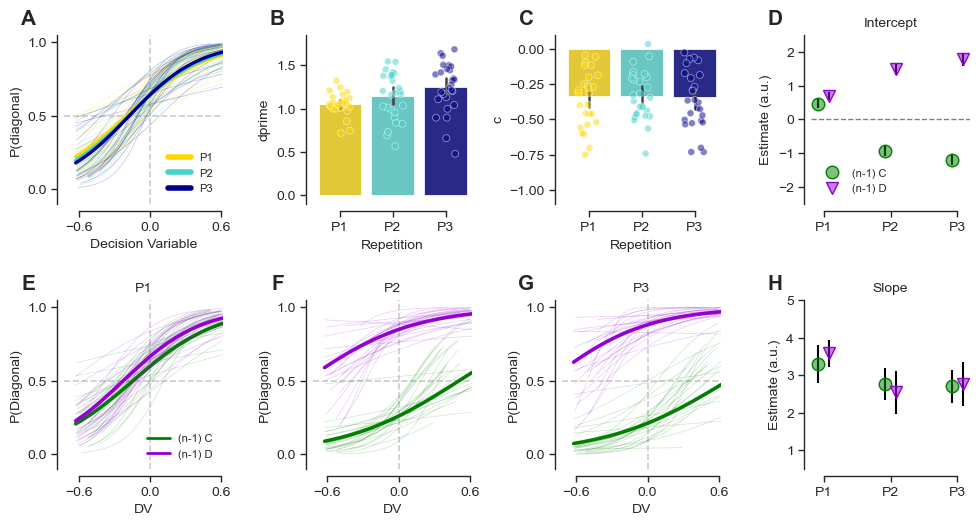

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import os
import string

# --- Global Setup ---
sns.set_theme(style="ticks", context="paper")

# Slightly expanded figsize to accommodate the outward ticks and despine offsets
fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))

EXP = '3reps'
# Se asume que estims, df, group_sdt_avg, colpal2, colpal3 y figures_path están definidos
estims = organize_data_betas(lmm_models['reps_exp']['md_3reps_exp'].coefs, 2, False)
titles = ['P1', 'P2', 'P3']
pre_deci_labels = np.unique(df['response1'])
id_subj_labels = np.unique(df.id_subj)
dat_main = df[df.exp_ID == EXP]
nreps = np.unique(dat_main['nrep'])

# =================================================================
# FILA 0: Métricas Globales + Intercept
# =================================================================

# --- Panel [0,0]: P(diagonal) ---
ax = axes[0, 0]
ax.axvline(0, ls='--', color='black', alpha=0.2)
ax.axhline(0.5, ls='--', color='black', alpha=0.2)
for i in id_subj_labels:
    dat2 = dat_main.loc[dat_main.id_subj == i, :]
    for cell in nreps:
        sns.regplot(x="rDV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0}, ci=True, n_boot=1, 
                    ax=ax, truncate=True, line_kws={'alpha': 0.3, 'lw': 0.4}, color=colpal2[cell])
for cell in nreps:
    sns.regplot(x="rDV", y="Responses", data=dat_main.loc[dat_main.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0}, ci=True, n_boot=1, 
                ax=ax, label=cell, truncate=True, line_kws={'lw': 2.4}, color=colpal2[cell])

ax.legend([Line2D([0], [0], color=c, lw=4) for c in colpal2], 
          ['P1', 'P2', 'P3'], loc='lower right', fontsize=8, framealpha=0.0)

ax.set_ylabel('P(diagonal)', fontsize=10)
ax.set_xlabel('Decision Variable', fontsize=10)
ax.set_xlim(-0.72, 0.62)
ax.set_xticks([-0.6, 0, 0.6])
ax.set_ylim(-0.1, 1.05)
ax.set_yticks([0.0, 0.5, 1])

# --- Panel [0,1]: dprime ---
ax = axes[0, 1]
dat_sdt = group_sdt_avg[group_sdt_avg.exp_ID == EXP]
sns.barplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.5, dodge=False, edgecolor="white", linewidth=0.6, jitter=0.2, palette=colpal2)
ax.set_ylabel("dprime", fontsize=10)
ax.set_xlabel('Repetition', fontsize=10)
ax.set_ylim(-0.1, 1.85)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['P1', 'P2', 'P3'])
if ax.get_legend(): ax.get_legend().remove()

# --- Panel [0,2]: c (criterion) ---
ax = axes[0, 2]
sns.barplot(data=dat_sdt, x="nrep", y="c", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat_sdt, x="nrep", y="c", hue="nrep", ax=ax, alpha=0.5, dodge=False, edgecolor="white", linewidth=0.6, jitter=0.2, palette=colpal2)
ax.set_ylabel("c", fontsize=10)
ax.set_xlabel('Repetition', fontsize=10)
ax.set_ylim(-1.1, 0.1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['P1', 'P2', 'P3'])
if ax.get_legend(): ax.get_legend().remove()

# =================================================================
# FILA 1: Psicofísicas Individuales (P1-P3) + Slope
# =================================================================

for j in nreps:
    ax = axes[1, j]
    ax.axvline(0, ls='--', color='black', alpha=0.2)
    ax.axhline(0.5, ls='--', color='black', alpha=0.2)
    for cell in pre_deci_labels:
        # LÍNEAS INDIVIDUALES
        for i in id_subj_labels:
            dati = dat_main[(dat_main.id_subj == i) & (dat_main['response1'] == cell) & (dat_main.nrep == j)].copy()
            if not dati.empty:
                sns.regplot(x="rDV", y="Responses", data=dati, logistic=True, y_jitter=0, 
                            scatter_kws={'alpha': 0}, ci=True, n_boot=1, truncate=True, 
                            line_kws={'alpha': 0.2, 'lw': 0.5}, ax=ax, color=colpal3[cell])
        
        # LÍNEA PROMEDIO
        datall = dat_main[(dat_main['response1'] == cell) & (dat_main.nrep == j)].copy()
        sns.regplot(x="rDV", y="Responses", data=datall, logistic=True, y_jitter=.0, 
                    scatter_kws={'alpha': 0}, ci=True, n_boot=1, truncate=True, 
                    line_kws={'lw': 2.6}, ax=ax, color=colpal3[cell])
    
    ax.set_title(titles[j], fontsize=10)
    ax.set_xlabel('DV', fontsize=10)
    ax.set_ylabel('P(Diagonal)', fontsize=10)
    ax.set_xlim(-0.72, 0.62)
    ax.set_xticks([-0.6, 0, 0.6])
    ax.set_ylim(-0.1, 1.05)
    ax.set_yticks([0.0, 0.5, 1])
    
    if j == 0:
        ax.legend([Line2D([0], [0], color=c, lw=2) for c in colpal3], ['(n-1) C', '(n-1) D'], loc='lower right', fontsize=8, framealpha=0.0)

# =================================================================
# PARÁMETROS DE REGRESIÓN: Intercept [0,3] y Slope [1,3]
# =================================================================
x_limits = [[-2.5, 2.5], [0.5, 5.0]]
params = [('bias', 'Intercept', 0), ('weight', 'Slope', 1)]
dodge_small = 0.08  

for iparam, title, row_idx in params:
    ax = axes[row_idx, 3]
    ax.set_title(title, fontsize=10)
    stim = estims[estims.parameter == iparam]
    
    ax.axhline(y=0, color='black', lw=1, ls="--", alpha=0.5)

    for h_idx, h_val in enumerate(np.unique(stim['prev_resp'])):
        subset = stim[stim['prev_resp'] == h_val].sort_values('nrep')
        x_pos = np.arange(len(nreps)) + (dodge_small if h_idx == 1 else -dodge_small)
        
        y_vals = subset['Estimate'].values
        yerr = [np.abs(y_vals - subset['2.5_ci'].values), 
                np.abs(subset['97.5_ci'].values - y_vals)]
        
        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o' if h_idx == 0 else 'v', 
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

    # Updated Intercept legend to match transparent marker shapes exactly
    if title == 'Intercept':
        lines = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=mcolors.to_rgba(colpal3[0], 0.5), markeredgecolor=colpal3[0], markersize=9),
            Line2D([0], [0], marker='v', color='w', markerfacecolor=mcolors.to_rgba(colpal3[1], 0.5), markeredgecolor=colpal3[1], markersize=9)
        ]
        ax.legend(lines, ['(n-1) C', '(n-1) D'], loc='lower left', fontsize=8, framealpha=0.0)

    ax.set_ylim(x_limits[row_idx])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['P1', 'P2', 'P3'])
    ax.set_xlabel('')


# =================================================================
# GLOBAL STYLING: SPINES, TICKS, & SMART X-BOUNDS
# =================================================================
panel_labels = list(string.ascii_uppercase)
for i, ax in enumerate(axes.flat):
    # Apply standard ticks and styling
    ax.tick_params(axis='both', which='major', bottom=True, left=True, 
                   direction='out', length=4, width=1, labelsize=10)
    sns.despine(ax=ax, offset=5, trim=False)
    
    # Dynamically bind the X-axis spine exactly to the first and last visible ticks
    fig.canvas.draw() # Force draw to populate ticks
    xticks = ax.get_xticks()
    xlim = ax.get_xlim()
    valid_ticks = [t for t in xticks if t >= xlim[0] and t <= xlim[1]]
    if len(valid_ticks) >= 2:
        ax.spines['bottom'].set_bounds(valid_ticks[0], valid_ticks[-1])
        
    # Apply panel labels
    ax.text(-0.18, 1.15, panel_labels[i], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout(pad=1.5)

figpath = os.path.join(figures_path, '3reps_final_proof_ready.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)
plt.show()

__Within sequence congruence between samples__

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_30772/921944295.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_30772/921944295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_30772/921944295.py:8: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0

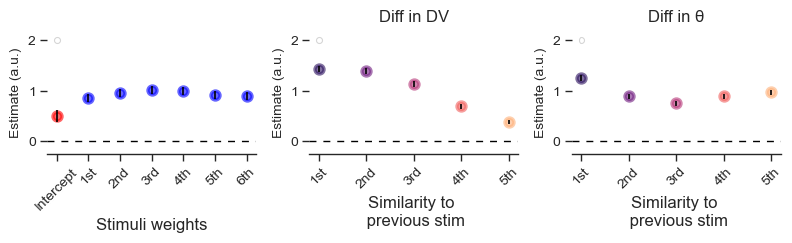

In [22]:
#estims = md_3reps_betas.copy()
fig, axes = plt.subplots(1, 3, figsize=(8,2.5))

# First I plot the betas of each stim and intercept
i = 0
#axes[i].set_title(iparam, fontsize=15)
stim = md_stim_coefs_3reps.copy()
g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
dodge=False, join=False, ci=None,scale=1.5,  palette = ['red','blue','blue','blue','blue','blue','blue'], errwidth=0, capsize=0, ax=axes[i], alpha = 0.6)
plt.setp(g.collections, alpha=.6) # set alpha for all points

# Find the x,y coordinates for each point
x_coords = []
y_coords = []
# Get the coordinates of each point

for ix, (cat, val) in enumerate(zip(stim['parameter'], stim['Estimate'])):
    x = stim['parameter'].unique().tolist().index(cat)
    y = val
    x_coords.append(x) # eliminate masked value
    y_coords.append(y)


axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

# Calculate error margins
yerr = np.array([stim['Estimate'] - stim['2.5_ci'], stim['97.5_ci'] - stim['Estimate']])

# Add error bars
axes[i].errorbar(x_coords, y_coords, yerr=yerr, fmt=' ', zorder=3, ecolor='black')

axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
axes[i].set_xlabel('Parameter', fontsize = 0)
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

axes[i].set_xlabel('Stimuli weights', fontsize = 12)
axes[i].margins(y=0.2)
axes[i].set_ylim([-.25, 2.2])
axes[i].set_yticks([0,1,2])
axes[i].set_xticklabels(['Intercept', '1st','2nd','3rd','4th','5th','6th'], rotation=45)
axes[i].tick_params(axis='y', labelsize=10) 
axes[i].tick_params(axis='x', labelsize=10) 

# Second, I plot the betas as a function of the physical and dv difference
sp_titles = ['Diff in DV','Diff in θ']

for i, iparam in enumerate(stim_models):
    i = i+1
    axes[i].set_title(sp_titles[i-1], fontsize=12)
    stim = iparam[iparam['parameter']  != '(Intercept)']
    g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
    dodge=False, join=False, ci=None,scale=1.5,  palette = "magma", errwidth=0, capsize=0, ax=axes[i], alpha = 0.6)
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    # Get the coordinates of each point
    for ix, (cat, val) in enumerate(zip(stim['parameter'], stim['Estimate'])):
        x = stim['parameter'].unique().tolist().index(cat)
        y = val

        x_coords.append(x) # eliminate masked value
        y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    #axes[i].spines['bottom'].set_visible(False)

    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
    
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlabel('Similarity to \n previous stim', fontsize = 12)
    axes[i].margins(y=0.2)
    axes[i].set_ylim([-.25, 2.2])
    axes[i].set_yticks([0,1,2])
    axes[i].set_xticklabels(['1st','2nd','3rd','4th','5th'], rotation=45)
    axes[i].tick_params(axis='x', labelsize=10) 
    axes[i].tick_params(axis='y', labelsize=10) 

fig.tight_layout(pad=1)

figpath = os.path.join(figures_path, '3reps_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

__DMM results__

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2463364524.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend(loc='best', fontsize=0, framealpha=0.0)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2463364524.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estims['mean'] = estims['mean'].astype(float)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2463364524.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

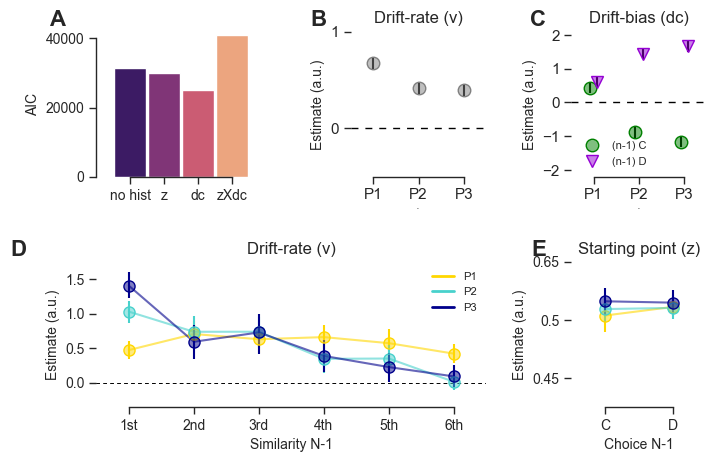

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import os
import string

EXP = '3reps'
# Set up the figure and GridSpec
fig = plt.figure(figsize=(7.5, 5))
gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1])

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # This subplot spans the first two columns
ax2 = fig.add_subplot(gs[0, 1])   # Single subplot
ax3 = fig.add_subplot(gs[0, 2])   # Single subplot
ax4 = fig.add_subplot(gs[1, 0:2])   # Single subplot
ax5 = fig.add_subplot(gs[1, 2])   # Single subplot

axes_params = [ax2, ax3]

# plotting models comparison
axis = ax1
dx = 'model'; dy = 'aic'; hue = 'model'; 
pal = 'magma' 
dat = modelfit[modelfit.exp_ID == EXP]
dat = dat[(dat.model != 'zXdcrepeat')]
dat['model'] = dat['model'].cat.remove_unused_categories()

g = sns.barplot(data=dat, x=dx, y=dy, hue=hue, dodge=False, linewidth=1, palette='magma', width=0.95, ax=axis)
g.set_xlabel("Model", fontsize=10)
g.set_ylabel("AIC", fontsize=10)
g.legend(loc='best', fontsize=0, framealpha=0.0)

ax1.set_ylim(0., 42000)
ax1.set_yticks([0.0, 2e4, 4e4]) 
ax1.tick_params(axis='y', labelsize=10) 

ax1.set_xticks([0, 1, 2, 3])
ax1.set_xticklabels(['no hist', 'z', 'dc', 'zXdc'])
ax1.tick_params(axis='x', labelsize=10) 
ax1.set_xlabel(None, fontdict={'size': 0})
ax1.set_xlim([-1, 4])
sns.despine(ax=ax1, offset=0.5, trim=True)
# Bounds the x-axis exactly from the first tick (0) to the last tick (3)
ax1.spines['bottom'].set_bounds(0, 3) 


# --- Panels B and C: params ddms (Replaced sns.pointplot with exact shapes from D and H) ---
y_limits = np.array([[-0.5, 1], [-2.2, 2.1]])
estims = ddms_params[(ddms_params.exp_ID == EXP) & (ddms_params.model == 'stimcoding_dc_prevresp')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)

sp_titles = ['Drift-rate (v)', 'Drift-bias (dc)']
dodge_small = 0.08  # Dodge for overlapping points

for j, jparam in enumerate(['v', 'dc']):
    ax = axes_params[j]
    ax.set_title(sp_titles[j], fontsize=12)
    stim = estims[(estims.param == jparam)]
    
    ax.axhline(y=0, color='black', linewidth=1, linestyle="dashed", dashes=(5, 5))

    if jparam == 'dc':
        unique_prevr = np.unique(stim['prevr'])
        for h_idx, h_val in enumerate(unique_prevr):
            subset = stim[stim['prevr'] == h_val].sort_values('nrep')
            
            # X positions with dodging
            x_pos = np.arange(len(subset['nrep'].unique())) + (dodge_small if h_idx == 1 else -dodge_small)
            y_vals = subset['mean'].values
            yerr = [np.abs(y_vals - subset['2.5q'].values), 
                    np.abs(subset['97.5q'].values - y_vals)]
            
            # Color logic matching your second script
            base_col = colpal3[h_idx]
            face_col = mcolors.to_rgba(base_col, alpha=0.5)
            
            ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o' if h_idx == 0 else 'v', 
                        color=base_col, mfc=face_col, mec=base_col,
                        markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

        # Legend with exact Marker shapes
        labels = ['(n-1) C', '(n-1) D']
        lines = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=mcolors.to_rgba(colpal3[0], 0.5), markeredgecolor=colpal3[0], markersize=9),
            Line2D([0], [0], marker='v', color='w', markerfacecolor=mcolors.to_rgba(colpal3[1], 0.5), markeredgecolor=colpal3[1], markersize=9)
        ]
        ax.legend(lines, labels, loc='lower left', fontsize=8, framealpha=0.0)

    else:
        # Drift-rate (v)
        subset = stim.sort_values('nrep')
        x_pos = np.arange(len(subset['nrep'].unique()))
        y_vals = subset['mean'].values
        yerr = [np.abs(y_vals - subset['2.5q'].values), 
                np.abs(subset['97.5q'].values - y_vals)]
        
        base_col = 'gray'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o', 
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.set_xlabel('nrep', fontsize=0)
    ax.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})
    
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['P1', 'P2', 'P3'])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_ylim(y_limits[j])
    ax.tick_params(axis='y', labelsize=11) 
    ax.tick_params(axis='x', labelsize=11) 
    ax.set_xlim([-0.5, 2.5])
    sns.despine(ax=ax, left=True, bottom=False, trim=True)
    # Bounds the x-axis exactly from the first tick (0) to the last tick (2)
    ax.spines['bottom'].set_bounds(0, 2)


# --- Panels D and E: Repetition similarity parameters ---
y_limits = np.array([[-0.35, 1.75] , [0.425, 0.55]])
estims = params_reg[(params_reg.exp == EXP) & (params_reg.model == 'stimcoding_diffprev')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)

parameters = ['v', 'z']
nreps = [0, 1, 2]
lines = [Line2D([0], [0], color=c, linewidth=2) for c in colpal2]

for x, xparam in enumerate(parameters):
    for y, yrep in enumerate(nreps):
        stim = estims[(estims.param == xparam) & (estims.nrep == yrep)]
        
        base_col = colpal2[y]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        if xparam == 'v':
            ax4.set_title('Drift-rate (v)', fontsize=12)
            
            x_coords = [stim['pos'].unique().tolist().index(cat) for cat in stim['pos']]
            y_coords = stim['mean'].values
            
            # Reverted to your exact original error math for ax4
            errs = np.array(stim[["2.5q","97.5q"]]).T
            errs = np.abs(errs)
            
            # Line + styled markers
            ax4.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax4.errorbar(x_coords, y_coords, yerr=errs, fmt='o', 
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col, capsize=0, zorder=3)

            ax4.set_ylim(y_limits[0])
            ax4.set_xlim([-0.5, 5.5])
            ax4.tick_params(axis='both', labelsize=10) 
            labels = ['P1', 'P2', 'P3']
            ax4.legend(lines, labels, loc='upper right', fontsize=8, framealpha=0.0)
            ax4.axhline(y=0, color='black', linewidth=0.5, linestyle="dashed", dashes=(5, 5))
            
            ax4.spines['top'].set_visible(False)
            ax4.spines['right'].set_visible(False)
            ax4.spines['left'].set_visible(False)
            ax4.set_xlabel('Similarity N-1', fontsize=10)
            ax4.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})
            ax4.margins(x=0.2)
            ax4.set_xticks([0, 1, 2, 3, 4, 5])
            ax4.set_xticklabels(['1st', '2nd', '3rd', '4th', '5th', '6th'])
            # Bounds the x-axis exactly from the first tick (0) to the last tick (5)
            ax4.spines['bottom'].set_bounds(0, 5)

        if xparam == 'z':
            ax5.set_title('Starting point (z)', fontsize=12)

            x_coords = [stim['prevr'].unique().tolist().index(cat) for cat in stim['prevr']]
            y_coords = stim['mean'].values
            
            # Reverted to your exact original error math for ax5
            errs = np.array(stim[["2.5q","97.5q"]]).T
            errs = np.abs(errs)
            
            # Line + styled markers
            ax5.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax5.errorbar(x_coords, y_coords, yerr=errs, fmt='o', 
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col, capsize=0, zorder=3)
            
            ax5.set_ylim(y_limits[1])
            ax5.set_xlim([-0.5, 1.5])
            ax5.tick_params(axis='both', labelsize=10) 
            
            ax5.spines['top'].set_visible(False)
            ax5.spines['right'].set_visible(False)
            ax5.spines['left'].set_visible(False)
            ax5.set_xlabel('Choice N-1', fontsize=10)
            ax5.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})
            
            ax5.set_yticks([0.45, 0.5, 0.55])
            ax5.set_yticklabels([0.45, 0.5, 0.65])
            ax5.set_xticks([0, 1])
            ax5.set_xticklabels(['C', 'D'])
            # Bounds the x-axis exactly from the first tick (0) to the last tick (1)
            ax5.spines['bottom'].set_bounds(0, 1)


# --- 5. Final Labeling (A, B, C, D, E) ---
axes_list = [ax1, ax2, ax3, ax4, ax5]
labels = list(string.ascii_uppercase)[:5]
for i, ax in enumerate(axes_list):
    ax.text(-0.18, 1.15, labels[i], transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='right')

fig.tight_layout(pad=2)

figpath = os.path.join(figures_path, '3reps_DDMreal.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)

# CJ experiment

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/1888657913.py:46: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/1888657913.py:47: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.5, dodge=False, edgecolor="white", linewidth=0.6, jitter=0.2, palette=colpal2)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/1888657913.py:55: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat_sdt, x="nrep", y="c", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/1

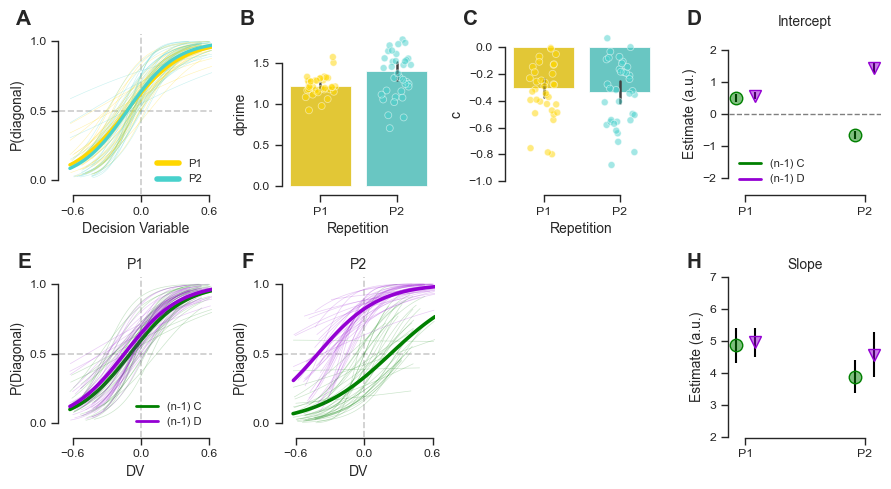

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import os
import string

# --- Configuración de la Figura (2 filas, 4 columnas) ---
fig, axes = plt.subplots(2, 4, figsize=(9, 5))

EXP = 'CJ'
# Se asume que estims, df, group_sdt_avg, colpal2, colpal3 y figures_path están definidos
estims = organize_data_betas(lmm_models['CJ_exp']['md_CJ_exp'].coefs, 1, False)
titles = ['P1', 'P2'] # Solo dos niveles para CJ
pre_deci_labels = np.unique(df['response1'])
id_subj_labels = np.unique(df.id_subj)
dat_main = df[df.exp_ID == EXP]
nreps = np.unique(dat_main['nrep']) # [0, 1]

# =================================================================
# FILA 0: Métricas Globales + Response Bias (Intercept)
# =================================================================

# --- Panel A [0,0]: P(diagonal) ---
ax = axes[0, 0]
ax.axvline(0, ls='--', color='black', alpha=0.2); ax.axhline(0.5, ls='--', color='black', alpha=0.2)
for i in id_subj_labels:
    dat2 = dat_main.loc[dat_main.id_subj == i, :]
    for cell in nreps:
        sns.regplot(x="rDV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0}, ci=True, n_boot=1, 
                    ax=ax, truncate=True, line_kws={'alpha': 0.3, 'lw': 0.4}, color=colpal2[cell])
for cell in nreps:
    sns.regplot(x="rDV", y="Responses", data=dat_main.loc[dat_main.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0}, ci=True, n_boot=1, 
                ax=ax, label=cell, truncate=True, line_kws={'lw': 2.4}, color=colpal2[cell])
ax.legend([Line2D([0], [0], color=c, lw=4) for c in colpal2[:2]], titles, loc='lower right', fontsize=8, framealpha=0.0)
ax.set_ylabel('P(diagonal)', fontsize=10); ax.set_xlabel('Decision Variable', fontsize=10)
ax.set_xlim(-0.72, 0.62); ax.set_xticks([-0.6, 0, 0.6]); ax.set_ylim(-0.1, 1.05); ax.set_yticks([0.0, 0.5, 1])
sns.despine(ax=ax, offset=0.5, trim=True)

# --- Panel B [0,1]: dprime ---
ax = axes[0, 1]
dat_sdt = group_sdt_avg[group_sdt_avg.exp_ID == EXP]
sns.barplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat_sdt, x="nrep", y="dprime", hue="nrep", ax=ax, alpha=0.5, dodge=False, edgecolor="white", linewidth=0.6, jitter=0.2, palette=colpal2)
ax.set_ylabel("dprime", fontsize=10); ax.set_xlabel('Repetition', fontsize=10); ax.set_ylim(-0.1, 1.85)
ax.set_xticks([0, 1]); ax.set_xticklabels(titles)
if ax.get_legend(): ax.get_legend().remove()
sns.despine(ax=ax, offset=.5, trim=True)

# --- Panel C [0,2]: c (criterion) ---
ax = axes[0, 2]
sns.barplot(data=dat_sdt, x="nrep", y="c", hue="nrep", ax=ax, alpha=0.9, dodge=False, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat_sdt, x="nrep", y="c", hue="nrep", ax=ax, alpha=0.5, dodge=False, edgecolor="white", linewidth=0.6, jitter=0.2, palette=colpal2)
ax.set_ylabel("c", fontsize=10); ax.set_xlabel('Repetition', fontsize=10); ax.set_ylim(-1.1, 0.1)
ax.set_xticks([0, 1]); ax.set_xticklabels(titles)
if ax.get_legend(): ax.get_legend().remove()
sns.despine(ax=ax, offset=.5, trim=True)

# =================================================================
# FILA 1: Psicofísicas Individuales (P1-P2) + DV Bias (Slope)
# =================================================================

for j in nreps:
    ax = axes[1, j]
    ax.axvline(0, ls='--', color='black', alpha=0.2); ax.axhline(0.5, ls='--', color='black', alpha=0.2)
    for cell in pre_deci_labels:
        # LÍNEAS INDIVIDUALES
        for i in id_subj_labels:
            dati = dat_main[(dat_main.id_subj == i) & (dat_main['response1'] == cell) & (dat_main.nrep == j)].copy()
            if not dati.empty:
                sns.regplot(x="rDV", y="Responses", data=dati, logistic=True, y_jitter=0, 
                            scatter_kws={'alpha': 0}, ci=True, n_boot=1, truncate=True, 
                            line_kws={'alpha': 0.2, 'lw': 0.5}, ax=ax, color=colpal3[cell])
        # LÍNEA PROMEDIO
        datall = dat_main[(dat_main['response1'] == cell) & (dat_main.nrep == j)].copy()
        sns.regplot(x="rDV", y="Responses", data=datall, logistic=True, y_jitter=.0, 
                    scatter_kws={'alpha': 0}, ci=True, n_boot=1, truncate=True, 
                    line_kws={'lw': 2.6}, ax=ax, color=colpal3[cell])
    
    ax.set_title(titles[j], fontsize=10); ax.set_xlabel('DV', fontsize=10); ax.set_ylabel('P(Diagonal)', fontsize=10)
    ax.set_xlim(-0.72, 0.62); ax.set_xticks([-0.6, 0, 0.6]); ax.set_ylim(-0.1, 1.05); ax.set_yticks([0.0, 0.5, 1])
    sns.despine(ax=ax, offset=0.5, trim=True)
    if j == 0:
        ax.legend([Line2D([0], [0], color=c, lw=2) for c in colpal3], ['(n-1) C', '(n-1) D'], loc='lower right', fontsize=8, framealpha=0.0)

# =================================================================
# PARÁMETROS DE REGRESIÓN: Response bias [0,3] y DV bias [1,3]
# =================================================================
x_limits = [[-2.5, 2.5], [2, 7]]
sp_titles = ['Intercept', 'Slope']
params = [('bias', sp_titles[0], 0), ('weight', sp_titles[1], 1)]
dodge_small = 0.08  

for iparam, title, row_idx in params:
    ax = axes[row_idx, 3]
    ax.set_title(title, fontsize=10)
    stim = estims[estims.parameter == iparam]
    ax.axhline(y=0, color='black', lw=1, ls="--", alpha=0.5)

    for h_idx, h_val in enumerate(np.unique(stim['prev_resp'])):
        subset = stim[stim['prev_resp'] == h_val].sort_values('nrep')
        x_pos = np.arange(len(nreps)) + (dodge_small if h_idx == 1 else -dodge_small)
        
        y_vals = subset['Estimate'].values
        yerr = [np.abs(y_vals - subset['2.5_ci'].values), 
                np.abs(subset['97.5_ci'].values - y_vals)]
        
        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o' if h_idx == 0 else 'v', 
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

    if row_idx == 0: # Leyenda solo en el primer panel de regresión
        ax.legend([Line2D([0], [0], color=c, lw=2) for c in colpal3], 
                  ['(n-1) C', '(n-1) D'], loc='lower left', fontsize=8, framealpha=0.0)

    ax.set_ylim(x_limits[row_idx]); ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(titles); ax.set_xlabel('')
    sns.despine(ax=ax, offset=0.5, trim=True)

# =================================================================
# ETIQUETADO DE PANELES (A, B, C...) Y OCULTAR VACÍOS
# =================================================================
panel_labels = list(string.ascii_uppercase)
for i, ax in enumerate(axes.flat):
    if i == 6: # El panel G (1,2) está vacío para este experimento
        ax.set_visible(False)
        continue
    ax.text(-0.18, 1.15, panel_labels[i], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.savefig(os.path.join(figures_path, 'CJ_final_proof_ready.pdf'), bbox_inches='tight', dpi=300)
plt.show()

__Within sequence congruence between samples__

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/4175457163.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/4175457163.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/4175457163.py:8: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/rx/vfyhhpqd7q172_xk2p75xp

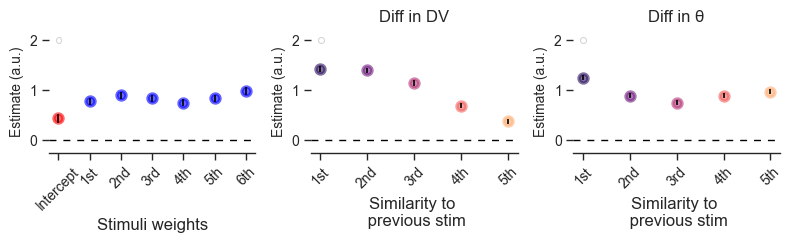

In [41]:

#estims = md_3reps_betas.copy()
fig, axes = plt.subplots(1, 3, figsize=(8,2.5))

# First I plot the betas of each stim and intercept
i = 0
#axes[i].set_title(iparam, fontsize=15)
stim = md_stim_coefs_CJ.copy()
g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
dodge=False, join=False, ci=None,scale=1.5,  palette = ['red','blue','blue','blue','blue','blue','blue'], errwidth=0, capsize=0, ax=axes[i], alpha = 0.6)
plt.setp(g.collections, alpha=.6) # set alpha for all points

# Find the x,y coordinates for each point
x_coords = []
y_coords = []
# Get the coordinates of each point
for ix, (cat, val) in enumerate(zip(stim['parameter'], stim['Estimate'])):
    x = stim['parameter'].unique().tolist().index(cat)
    y = val
    x_coords.append(x) # eliminate masked value
    y_coords.append(y)


axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

# Calculate error margins
yerr = np.array([stim['Estimate'] - stim['2.5_ci'], stim['97.5_ci'] - stim['Estimate']])

# Add error bars
axes[i].errorbar(x_coords, y_coords, yerr=yerr, fmt=' ', zorder=3, ecolor='black')

axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
axes[i].set_xlabel('Parameter', fontsize = 0)
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

axes[i].set_xlabel('Stimuli weights', fontsize = 12)
axes[i].margins(y=0.2)
axes[i].set_ylim([-.25, 2.2])
axes[i].set_yticks([0,1,2])
axes[i].set_xticklabels(['Intercept', '1st','2nd','3rd','4th','5th','6th'], rotation=45)
axes[i].tick_params(axis='y', labelsize=10) 
axes[i].tick_params(axis='x', labelsize=10) 

# Second, I plot the betas as a function of the physical and dv difference
sp_titles = ['Diff in DV','Diff in θ']

for i, iparam in enumerate(stim_models):
    i = i+1
    axes[i].set_title(sp_titles[i-1], fontsize=12)
    stim = iparam[iparam['parameter']  != '(Intercept)']
    g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
    dodge=False, join=False, ci=None,scale=1.5,  palette = "magma", errwidth=0, capsize=0, ax=axes[i], alpha = 0.6)
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    # Get the coordinates of each point
    for ix, (cat, val) in enumerate(zip(stim['parameter'], stim['Estimate'])):
        x = stim['parameter'].unique().tolist().index(cat)
        y = val

        x_coords.append(x) # eliminate masked value
        y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    #axes[i].spines['bottom'].set_visible(False)

    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
    
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlabel('Similarity to \n previous stim', fontsize = 12)
    axes[i].margins(y=0.2)
    axes[i].set_ylim([-.25, 2.2])
    axes[i].set_yticks([0,1,2])
    axes[i].set_xticklabels(['1st','2nd','3rd','4th','5th'], rotation=45)
    axes[i].tick_params(axis='x', labelsize=10) 
    axes[i].tick_params(axis='y', labelsize=10) 

fig.tight_layout(pad=1)

figpath = os.path.join(figures_path, 'CJ_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

DDM parameters

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2806421919.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend(loc='best', fontsize=0, framealpha=0.0)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2806421919.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estims['mean'] = estims['mean'].astype(float)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31148/2806421919.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

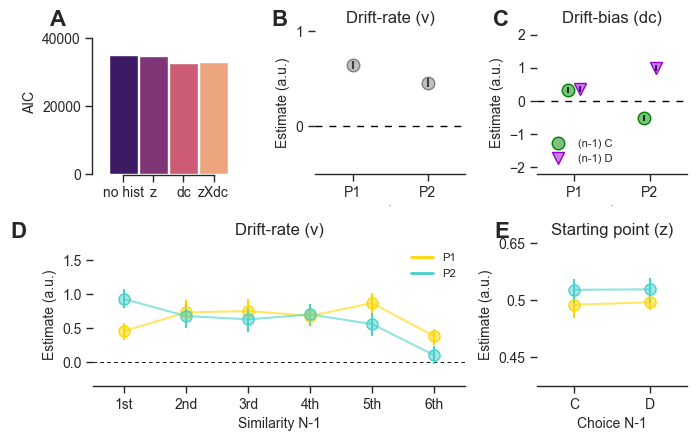

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import os
import string

EXP = 'CJ'

# Set up the figure and GridSpec
fig = plt.figure(figsize=(7, 4.5))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1])

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # This subplot spans the first two columns
ax2 = fig.add_subplot(gs[0, 1])   # Single subplot
ax3 = fig.add_subplot(gs[0, 2])   # Single subplot
ax4 = fig.add_subplot(gs[1, 0:2])   # Single subplot
ax5 = fig.add_subplot(gs[1, 2])   # Single subplot

axes_params = [ax2, ax3]

# --- 1. Plotting Models Comparison ---
axis = ax1
dx = 'model'; dy = 'aic'; hue = 'model'
pal = 'magma'
dat = modelfit[modelfit.exp_ID == EXP]
dat = dat[(dat.model != 'zXdcrepeat')]
dat['model'] = dat['model'].cat.remove_unused_categories()

g = sns.barplot(data=dat, x=dx, y=dy, hue=hue, dodge=False, linewidth=1, palette='magma', width=0.95, ax=axis)
g.set_xlabel("Model", fontsize=10)
g.set_ylabel("AIC", fontsize=10)
g.legend(loc='best', fontsize=0, framealpha=0.0)

ax1.set_ylim(0., 42000)
ax1.set_yticks([0.0, 2e4, 4e4]) 
ax1.tick_params(axis='y', labelsize=10) 

ax1.set_xticks([0, 1, 2, 3])
ax1.tick_params(axis='x', labelsize=10) 
ax1.set_xlabel(None, fontdict={'size': 0})
ax1.set_xlim([-1, 4])
ax1.set_xticklabels(['no hist', 'z', 'dc', 'zXdc'], rotation=45)
sns.despine(ax=ax1, offset=0.5, trim=True)


# --- 2. Params DDMs (ax2, ax3) ---
y_limits = np.array([[-0.5, 1], [-2.2, 2.1]])

estims = ddms_params[(ddms_params.exp_ID == EXP) & (ddms_params.model == 'stimcoding_dc_prevresp')] 
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)

sp_titles = ['Drift-rate (v)', 'Drift-bias (dc)']
dodge_small = 0.08  # Dodge for overlapping points

for j, jparam in enumerate(['v', 'dc']):
    ax = axes_params[j]
    ax.set_title(sp_titles[j], fontsize=12)
    stim = estims[(estims.param == jparam)]
    
    ax.axhline(y=0, color='black', linewidth=1, linestyle="dashed", dashes=(5, 5))

    if jparam == 'dc':
        unique_prevr = np.unique(stim['prevr'])
        for h_idx, h_val in enumerate(unique_prevr):
            subset = stim[stim['prevr'] == h_val].sort_values('nrep')
            
            # X positions with dodging
            x_pos = np.arange(len(subset['nrep'].unique())) + (dodge_small if h_idx == 1 else -dodge_small)
            y_vals = subset['mean'].values
            
            # Error logic identical to target script: (mean - 2.5q, 97.5q - mean)
            yerr = [np.abs(y_vals - subset['2.5q'].values), 
                    np.abs(subset['97.5q'].values - y_vals)]
            
            base_col = colpal3[h_idx]
            face_col = mcolors.to_rgba(base_col, alpha=0.5)
            
            ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o' if h_idx == 0 else 'v', 
                        color=base_col, mfc=face_col, mec=base_col,
                        markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

        # Legend mapping
        labels = ['(n-1) C', '(n-1) D']
        lines = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=mcolors.to_rgba(colpal3[0], 0.5), markeredgecolor=colpal3[0], markersize=9),
            Line2D([0], [0], marker='v', color='w', markerfacecolor=mcolors.to_rgba(colpal3[1], 0.5), markeredgecolor=colpal3[1], markersize=9)
        ]
        ax.legend(lines, labels, loc='lower left', fontsize=8, framealpha=0.0)

    else:
        # Drift-rate (v)
        subset = stim.sort_values('nrep')
        x_pos = np.arange(len(subset['nrep'].unique()))
        y_vals = subset['mean'].values
        yerr = [np.abs(y_vals - subset['2.5q'].values), 
                np.abs(subset['97.5q'].values - y_vals)]
        
        base_col = 'gray'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o', 
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black', capsize=0, zorder=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.set_xlabel('nrep', fontsize=0)
    ax.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['P1', 'P2'])

    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_ylim(y_limits[j])
    ax.tick_params(axis='y', labelsize=10) 
    ax.tick_params(axis='x', labelsize=10) 
    ax.set_xlim(-0.5, 1.5)


# --- 3. Repetition Similarity Parameters (ax4, ax5) ---
y_limits = np.array([[-0.35, 1.75], [0.425, 0.55]])
estims = params_reg[(params_reg.exp == EXP) & (params_reg.model == 'stimcoding_diffprev')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)

parameters = ['v', 'z']
nreps = [0, 1]
lines = [Line2D([0], [0], color=c, linewidth=2) for c in colpal2]

for x, xparam in enumerate(parameters):
    for y, yrep in enumerate(nreps):
        stim = estims[(estims.param == xparam) & (estims.nrep == yrep)]
        
        base_col = colpal2[y]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        
        if xparam == 'v':
            ax4.set_title('Drift-rate (v)', fontsize=12)
            
            x_coords = [stim['pos'].unique().tolist().index(cat) for cat in stim['pos']]
            y_coords = stim['mean'].values
            
            # Error math exact to your ax4 target
            errs = np.array(stim[["2.5q", "97.5q"]]).T
            errs = np.abs(errs)
            
            # Line + styled markers
            ax4.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax4.errorbar(x_coords, y_coords, yerr=errs, fmt='o', 
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col, capsize=0, zorder=3)

            ax4.set_ylim(y_limits[0])
            ax4.set_xlim([-0.5, 5.5])
            
            ax4.tick_params(axis='both', labelsize=10) 

            labels = ['P1', 'P2']
            ax4.legend(lines, labels, loc='upper right', fontsize=8, framealpha=0.0)
            ax4.axhline(y=0, color='black', linewidth=0.5, linestyle="dashed", dashes=(5, 5))
            
            ax4.spines['top'].set_visible(False)
            ax4.spines['right'].set_visible(False)
            ax4.spines['left'].set_visible(False)
            
            ax4.set_xlabel('Similarity N-1', fontsize=10)
            ax4.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})
            ax4.margins(x=0.2)
            ax4.set_xticks([0, 1, 2, 3, 4, 5])
            ax4.set_xticklabels(['1st', '2nd', '3rd', '4th', '5th', '6th'])

        if xparam == 'z':
            ax5.set_title('Starting point (z)', fontsize=12)

            x_coords = [stim['prevr'].unique().tolist().index(cat) for cat in stim['prevr']]
            y_coords = stim['mean'].values

            # Error math exact to your ax5 target
            errs = np.array(stim[["2.5q", "97.5q"]]).T
            errs = np.abs(errs)

            # Line + styled markers
            ax5.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax5.errorbar(x_coords, y_coords, yerr=errs, fmt='o', 
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col, capsize=0, zorder=3)
            
            ax5.set_ylim(y_limits[1])
            ax5.set_xlim([-0.5, 1.5])
            ax5.tick_params(axis='both', labelsize=10) 
            
            ax5.spines['top'].set_visible(False)
            ax5.spines['right'].set_visible(False)
            ax5.spines['left'].set_visible(False)
            ax5.set_xlabel('Choice N-1', fontsize=10)
            ax5.set_ylabel('Estimate (a.u.)', fontdict={'size': 10})
            
            ax5.set_xticks([0, 1])
            ax5.set_xticklabels(['C', 'D'])
            ax5.set_yticks([0.45, 0.5, 0.55])
            ax5.set_yticklabels([0.45, 0.5, 0.65])


# --- 4. Final Formatting ---
# (Adding the panel labels A, B, C... to match your visual standard if desired)
axes_list = [ax1, ax2, ax3, ax4, ax5]
panel_labels = list(string.ascii_uppercase)[:5]
for i, ax in enumerate(axes_list):
    ax.text(-0.18, 1.15, panel_labels[i], transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='right')

fig.tight_layout(pad=1)

figpath = os.path.join(figures_path, 'CJ_DDMreal.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)

__Analyzing metadprime values for CJ experiment__

In [60]:

#Checking statistical differences in Weight between the number of repetitions & previous decision
pg.rm_anova(dv = 'mean', within = ['nrep', 'blocktype'], subject = 'subj', 
            data=meta_dprimes, detailed = True, correction = True)

/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,nrep,0.042282,1,34,0.042282,1.438867,0.238615,0.238615,0.005034,1.0
1,blocktype,0.454746,1,34,0.454746,5.413283,0.026078,0.026078,0.051605,1.0
2,nrep * blocktype,0.050806,1,34,0.050806,2.052105,0.161127,0.161127,0.006043,1.0


In [302]:
meta_dprimes

,subj,nrep,blocktype,level_3,nrep_metad,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,exp_ID
0,s01,0,nonrepeat,meta_d,0.022,0.329,-0.549,0.667,0.010,0.008,1176.0,1386.0,1.0,CJ
1,s01,0,repeat,meta_d,0.177,0.332,-0.442,0.795,0.010,0.007,1051.0,1114.0,1.0,CJ
2,s01,1,nonrepeat,meta_d,-0.141,0.337,-0.782,0.471,0.010,0.008,1173.0,1063.0,1.0,CJ
3,s01,1,repeat,meta_d,-0.033,0.313,-0.606,0.576,0.008,0.007,1408.0,1316.0,1.0,CJ
4,s02,0,nonrepeat,meta_d,0.218,0.340,-0.402,0.856,0.010,0.007,1171.0,1229.0,1.0,CJ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,s38,1,repeat,meta_d,0.254,0.233,-0.165,0.695,0.008,0.005,914.0,1188.0,1.0,CJ
148,s39,0,nonrepeat,meta_d,0.197,0.255,-0.260,0.680,0.008,0.005,1103.0,1309.0,1.0,CJ
149,s39,0,repeat,meta_d,0.455,0.264,-0.004,0.957,0.008,0.006,1037.0,1376.0,1.0,CJ
150,s39,1,nonrepeat,meta_d,0.135,0.269,-0.407,0.604,0.009,0.006,979.0,1216.0,1.0,CJ


<Axes: xlabel='nrep', ylabel='nrep_metad_eff'>

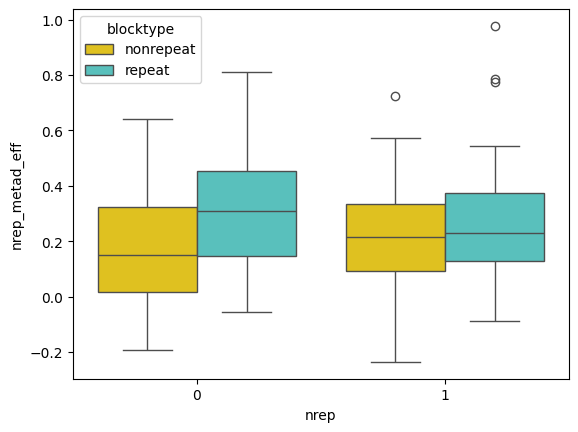

In [320]:
sns.boxplot(data = meta_dprimes, x = 'nrep', y = 'nrep_metad_eff', hue = 'blocktype')


In [31]:
indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)
indiv_sdt.reset_index(inplace=True)
merged_sdt = pd.merge( df[df.nrep == 0][['metad', 'id_subj']], indiv_sdt,on = ['id_subj'], how = 'inner') 
merged_sdt.drop_duplicates(subset = ['id_subj'], inplace = True)
merged_sdt['metad_eff'] = merged_sdt['metad'] / merged_sdt['dprime']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/3067209949.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)


Calculating difference in enhancement between 2 and 1 repetition

In [32]:
dat = df[df.exp_ID == 'CJ'].copy()
CJ_blocktype_avg_correct = dat.groupby(['exp_ID', 'id_subj','nrep','trial_type'],as_index=False)[['accuracy','rt', 'Confidence']].mean()
CJ_blocktype_sdt_avg = dat.groupby(['exp_ID', 'id_subj','nrep','trial_type']).apply(sdt)
CJ_blocktype_sdt_avg.reset_index(inplace=True)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/2320819804.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CJ_blocktype_sdt_avg = dat.groupby(['exp_ID', 'id_subj','nrep','trial_type']).apply(sdt)


In [33]:
CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)
CJ_df.reset_index(inplace=True)
CJ_df_diff = CJ_df[CJ_df.nrep == 1].reset_index(drop=True)
aux = CJ_df[CJ_df.nrep == 0].reset_index(drop=True)
CJ_df_diff['diffdprime'] = CJ_df_diff['dprime'] - aux['dprime']

# Merging all the CJ dataframes
metacog_df = pd.merge( merged_sdt[merged_sdt['exp_ID'] == 'CJ'], CJ_df_diff[['diffdprime', 'id_subj', 'exp_ID']],on = ['id_subj','exp_ID'], how = 'inner') 


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1930052990.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)


There are no differences in confidence nor in sensitivity between repeat and not repeat...

In [34]:
#Checking statistical differences in Weight between the number of repetitions & previous decision
pg.rm_anova(dv = 'Confidence', within = ['nrep', 'trial_type'], subject = 'id_subj', 
            data=CJ_blocktype_avg_correct, detailed = True, correction = True)

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,nrep,10.361043,1,36,10.361043,35.499093,7.905206e-07,7.905206e-07,0.053955,1.0
1,trial_type,0.002935,1,36,0.002935,0.016394,8.988291e-01,8.988291e-01,0.000016,1.0
2,nrep * trial_type,0.109340,1,36,0.109340,3.416808,7.276288e-02,7.276288e-02,0.000601,1.0


In [310]:
#Checking statistical differences in Weight between the number of repetitions & previous decision
pg.rm_anova(dv = 'dprime', within = ['nrep', 'trial_type'], subject = 'id_subj', 
            data=CJ_blocktype_sdt_avg, detailed = True, correction = True)

/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,nrep,1.410758,1,36,1.410758,15.490343,0.000363,0.000363,0.091412,1.0
1,trial_type,0.004683,1,36,0.004683,0.061011,0.806308,0.806308,0.000334,1.0
2,nrep * trial_type,0.007406,1,36,0.007406,0.125293,0.725428,0.725428,0.000528,1.0


In [311]:
#Checking statistical differences in Weight between the number of repetitions & previous decision
pg.rm_anova(dv = 'c', within = ['nrep', 'trial_type'], subject = 'id_subj', 
            data=CJ_blocktype_sdt_avg, detailed = True, correction = True)

/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/anaconda3/envs/HSSM/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,nrep,0.056986,1,36,0.056986,2.591813,0.116152,0.116152,0.005770,1.0
1,trial_type,0.020482,1,36,0.020482,0.711928,0.404376,0.404376,0.002081,1.0
2,nrep * trial_type,0.043941,1,36,0.043941,3.508273,0.069201,0.069201,0.004455,1.0


<Axes: xlabel='nrep', ylabel='Confidence'>

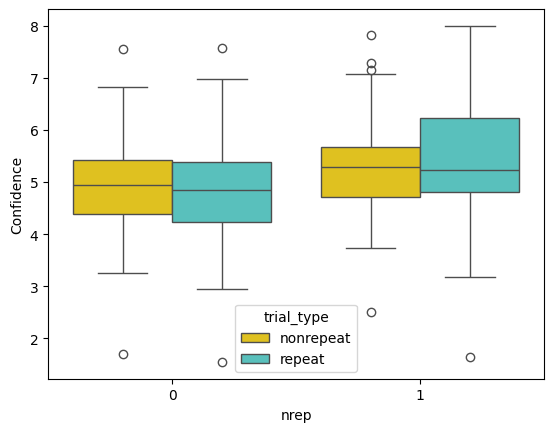

In [313]:
sns.boxplot(data = CJ_blocktype_avg_correct, x = 'nrep', y = 'Confidence', hue = 'trial_type')


## __CJ metadprime effect__

In [59]:
sns.set_theme()
import matplotlib as mpl

mpl.rcdefaults()

In [66]:
sns.set_theme(style="ticks", context="paper")

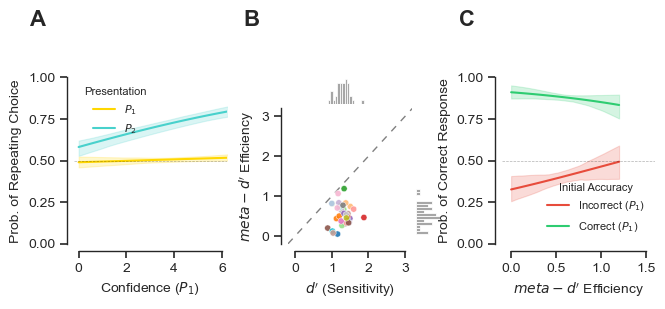

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.transforms as mtransforms
import os

# --- 1. RELOAD DATA ---
# final_plot_df = pd.read_csv('./all_data_CSV/plot_CJ_confidence_repeat.csv')
# final_summary = pd.read_csv('./all_data_CSV/plot_CJ_metad_repeat.csv')
# pred_grid = pd.read_csv('./all_data_CSV/plot_CJ_metad_accuracy.csv')

# --- 2. FIGURE SETUP ---
sns.set_theme(style="ticks", context="paper")

fig = plt.figure(figsize=(7.5, 2.25)) 
gs = gridspec.GridSpec(1, 3, wspace=0.4, top=0.85)

# Scaled down Style Settings
LBL_FONT = 10
TIC_FONT = 10
LEG_FONT = 8
PANEL_FONT = 16
LINE_W = 1.5
SCATTER_S = 20
y_ticks_prob = [0, 0.25, 0.5, 0.75, 1.0]

# ------------------------------------------------------------------
# PANEL A: Confidence & Choice Consistency
# ------------------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
palette_rep = {'$P_1$': 'gold', '$P_2$': 'mediumturquoise'}
map_rep = {'Initial Presentation': '$P_1$', 'Repeated (Confirmation Bias)': '$P_2$'}

for old_cond, new_label in map_rep.items():
    subset = final_plot_df[final_plot_df['Condition'] == old_cond]
    if not subset.empty:
        ax0.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
                 label=new_label, color=palette_rep[new_label], linewidth=LINE_W)
        ax0.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                          color=palette_rep[new_label], alpha=0.2)

ax0.axhline(0.5, linestyle="--", color="black", linewidth=0.5, alpha=0.3)
ax0.set_yticks(y_ticks_prob)
ax0.set_ylim(0, 1)

# FIX: Explicitly set ticks so the axis bounds encompass the full data line
ax0.set_xticks([0, 2, 4, 6]) 
ax0.set_xlim(-0.2, 6.2)

ax0.set_xlabel("Confidence ($P_1$)", fontdict={'size': LBL_FONT})
ax0.set_ylabel("Prob. of Repeating Choice", fontdict={'size': LBL_FONT})
ax0.legend(title="Presentation", fontsize=LEG_FONT, title_fontsize=LEG_FONT, frameon=False, loc='upper left')

# ------------------------------------------------------------------
# PANEL B: SDT JOINTPLOT
# ------------------------------------------------------------------
gs_sdt = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], 
                                          width_ratios=[5, 1], height_ratios=[1, 5],
                                          wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs_sdt[1, 0])
ax_marg_x = fig.add_subplot(gs_sdt[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs_sdt[1, 1], sharey=ax_joint)

# Joint Scatter
sns.scatterplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', y='metad_eff', hue='id_subj', 
                palette='tab20', s=SCATTER_S, alpha=0.9, legend=False, ax=ax_joint)

# Marginals
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', color='gray', bins=15, alpha=0.7, ax=ax_marg_x, legend=False)
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], y='metad_eff', color='gray', bins=15, alpha=0.7, ax=ax_marg_y, legend=False)

# FIX: Expanded bounds to ensure ticks fully cover the data
min_val, max_val = -0.2, 3.2 
ax_joint.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='dashed', dashes=(5, 5), linewidth=1, zorder=0)

# FIX: Removed `ax_joint.set_aspect('equal')` to prevent the extreme compression
ax_joint.set_xlim(min_val, max_val); ax_joint.set_ylim(min_val, max_val)

# FIX: Added '3' to ensure the bounding spine reaches past the top data points
shared_ticks = [0, 1, 2, 3] 
ax_joint.set_xticks(shared_ticks); ax_joint.set_yticks(shared_ticks)
ax_joint.set_xlabel("$d'$ (Sensitivity)", fontdict={'size': LBL_FONT})
ax_joint.set_ylabel("$meta-d'$ Efficiency", fontdict={'size': LBL_FONT})

ax_marg_x.axis('off'); ax_marg_y.axis('off')

# ------------------------------------------------------------------
# PANEL C: Metacognition & Accuracy
# ------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
colors_acc = {'Incorrect ($P_1$)': '#e74c3c', 'Correct ($P_1$)': '#2ecc71'}
map_acc = {'0': 'Incorrect ($P_1$)', '1': 'Correct ($P_1$)'}

p_grid_filt = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy() if 'nrep' in pred_grid.columns else pred_grid.copy()
label_col = 'Previous_Accuracy' if 'Previous_Accuracy' in p_grid_filt.columns else 'accuracy1'

for old_val, new_label in map_acc.items():
    sub_data = p_grid_filt[p_grid_filt[label_col].astype(str).str.contains(str(old_val))]
    if not sub_data.empty:
        y_col = 'Predicted_Probability' if 'Predicted_Probability' in sub_data.columns else 'Mean_Prob'
        ax3.plot(sub_data['metad_eff'], sub_data[y_col], color=colors_acc[new_label], linewidth=LINE_W, label=new_label)
        ax3.fill_between(sub_data['metad_eff'], sub_data['CI_Lower'], sub_data['CI_Upper'], color=colors_acc[new_label], alpha=0.2)

ax3.axhline(0.5, linestyle="--", color="black", linewidth=0.5, alpha=0.3)
ax3.set_yticks(y_ticks_prob)
ax3.set_ylim(0, 1)

# FIX: Explicitly set ticks so the axis bounds encompass the full data line
ax3.set_xticks([0.0, 0.5, 1.0, 1.5])
ax3.set_xlim(-0.1, 1.6)

ax3.set_xlabel("$meta-d'$ Efficiency", fontdict={'size': LBL_FONT})
ax3.set_ylabel("Prob. of Correct Response", fontdict={'size': LBL_FONT})
ax3.legend(title="Initial Accuracy", fontsize=LEG_FONT, title_fontsize=LEG_FONT, frameon=False, loc='lower right')

# --- 3. FINAL CLEANUP (SPINES, TICKS, & LABELS) ---

for ax in [ax0, ax_joint, ax3]:
    sns.despine(ax=ax, offset=5, trim=False)
    
    ax.tick_params(axis='both', which='major', bottom=True, left=True, 
                   direction='out', length=5, width=1.2, labelsize=TIC_FONT)
    
    # Dynamically bind the X-axis spine exactly to the first and last visible ticks
    fig.canvas.draw() 
    xticks = ax.get_xticks()
    xlim = ax.get_xlim()
    valid_ticks = [t for t in xticks if t >= xlim[0] and t <= xlim[1]]
    if len(valid_ticks) >= 2:
        ax.spines['bottom'].set_bounds(valid_ticks[0], valid_ticks[-1])

# Blended transforms ensure A, B, and C are perfectly level globally
Y_ALIGN = 1.15 
X_ALIGN = -0.18

transA = mtransforms.blended_transform_factory(ax0.transAxes, fig.transFigure)
ax0.text(X_ALIGN, Y_ALIGN, 'A', transform=transA, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transB = mtransforms.blended_transform_factory(ax_joint.transAxes, fig.transFigure)
ax_joint.text(X_ALIGN - 0.05, Y_ALIGN, 'B', transform=transB, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transC = mtransforms.blended_transform_factory(ax3.transAxes, fig.transFigure)
ax3.text(X_ALIGN, Y_ALIGN, 'C', transform=transC, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

# --- 4. EXPORT ---
figpath = os.path.join(figures_path, 'CJ_behavioral_styled.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)
plt.show()

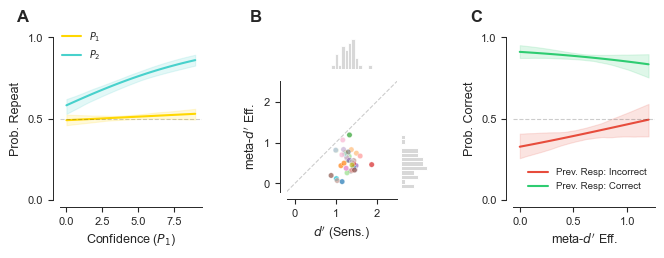

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.transforms as mtransforms
import os

# --- 1. DATA LOADING (Assuming variables are in namespace) ---
# final_plot_df, pred_grid, merged_sdt should be pre-loaded

# --- 2. FIGURE SETUP (SCALED FOR 7x2.5) ---
fig = plt.figure(figsize=(7, 2.5)) 
gs = gridspec.GridSpec(1, 3, wspace=0.6, top=0.85, bottom=0.2, left=0.1, right=0.95)

# Scaled Style Settings
LBL_FONT = 9; TIC_FONT = 8; LEG_FONT = 7; PANEL_FONT = 12
y_ticks_prob = [0, 0.5, 1.0]

# ------------------------------------------------------------------
# PANEL A: Confidence & Choice Consistency
# ------------------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
palette_rep = {'$P_1$': 'gold', '$P_2$': 'mediumturquoise'}
map_rep = {'Initial Presentation': '$P_1$', 'Repeated (Confirmation Bias)': '$P_2$'}

for old_cond, new_label in map_rep.items():
    subset = final_plot_df[final_plot_df['Condition'] == old_cond]
    if not subset.empty:
        ax0.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
                 label=new_label, color=palette_rep[new_label], linewidth=1.5)
        ax0.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                         color=palette_rep[new_label], alpha=0.15)

ax0.axhline(0.5, linestyle="--", color="black", alpha=0.2, lw=0.8)
ax0.set_yticks(y_ticks_prob); ax0.set_ylim(0, 1)
ax0.set_xlabel("Confidence ($P_1$)", fontsize=LBL_FONT)
ax0.set_ylabel("Prob. Repeat", fontsize=LBL_FONT)
ax0.legend(fontsize=LEG_FONT, frameon=False, loc='upper left', bbox_to_anchor=(-0.05, 1.1), ncol=1)

# ------------------------------------------------------------------
# PANEL B: SDT JOINTPLOT
# ------------------------------------------------------------------
gs_sdt = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], 
                                          width_ratios=[4, 1], height_ratios=[1, 4],
                                          wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs_sdt[1, 0])
ax_marg_x = fig.add_subplot(gs_sdt[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs_sdt[1, 1], sharey=ax_joint)

sns.scatterplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', y='metad_eff', 
                hue='id_subj', palette='tab20', s=15, alpha=0.7, legend=False, ax=ax_joint)

sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', color='gray', bins=12, alpha=0.3, ax=ax_marg_x)
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], y='metad_eff', color='gray', bins=12, alpha=0.3, ax=ax_marg_y)

ax_joint.plot([-0.2, 2.5], [-0.2, 2.5], color='black', linestyle='--', lw=0.8, alpha=0.2, zorder=0)
ax_joint.set_aspect('equal')
ax_joint.set_xlim(-0.2, 2.5); ax_joint.set_ylim(-0.2, 2.5)
ax_joint.set_xticks([0, 1, 2]); ax_joint.set_yticks([0, 1, 2])
ax_joint.set_xlabel("$d'$ (Sens.)", fontsize=LBL_FONT)
ax_joint.set_ylabel("meta-$d'$ Eff.", fontsize=LBL_FONT)

ax_marg_x.axis('off'); ax_marg_y.axis('off')

# ------------------------------------------------------------------
# PANEL C: Metacognition & Accuracy
# ------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
colors_acc = {'Incorrect ($P_1$)': '#e74c3c', 'Correct ($P_1$)': '#2ecc71'}
map_acc = {'0': 'Incorrect', '1': 'Correct'}

p_grid_filt = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy() if 'nrep' in pred_grid.columns else pred_grid.copy()
label_col = 'Previous_Accuracy' if 'Previous_Accuracy' in p_grid_filt.columns else 'accuracy1'

for old_val, new_label in map_acc.items():
    sub_data = p_grid_filt[p_grid_filt[label_col].astype(str).str.contains(str(old_val))]
    if not sub_data.empty:
        y_col = 'Predicted_Probability' if 'Predicted_Probability' in sub_data.columns else 'Mean_Prob'
        
        # ---> Added "Prev. Response:" to the label here <---
        ax3.plot(sub_data['metad_eff'], sub_data[y_col], color=colors_acc[f"{new_label} ($P_1$)"], linewidth=1.5, label=f"Prev. Resp: {new_label}")
        ax3.fill_between(sub_data['metad_eff'], sub_data['CI_Lower'], sub_data['CI_Upper'], color=colors_acc[f"{new_label} ($P_1$)"], alpha=0.15)

ax3.axhline(0.5, linestyle="--", color="black", alpha=0.2, lw=0.8)
ax3.set_yticks(y_ticks_prob); ax3.set_ylim(0, 1)
ax3.set_xlabel("meta-$d'$ Eff.", fontsize=LBL_FONT)
ax3.set_ylabel("Prob. Correct", fontsize=LBL_FONT)
ax3.legend(fontsize=LEG_FONT, frameon=False, loc='lower right')

# --- 3. FINAL CLEANUP (THINNER AXES & TICKS) ---

for ax in [ax0, ax_joint, ax3]:
    sns.despine(ax=ax, offset=5)
    
    # Set spine thickness (thinner)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(0.7)
    
    # Set tick thickness (match the spines)
    ax.tick_params(axis='both', which='major', bottom=True, left=True, 
                   direction='out', length=3.5, width=0.8, labelsize=TIC_FONT)

# Panel Labels
Y_ALIGN = 0.96 
for i, axis in enumerate([ax0, ax_joint, ax3]):
    label = ['A', 'B', 'C'][i]
    trans = mtransforms.blended_transform_factory(axis.transAxes, fig.transFigure)
    axis.text(-0.22, Y_ALIGN, label, transform=trans, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

# --- 4. EXPORT ---
plt.savefig(os.path.join(figures_path, 'CJ_behavioral_thin.pdf'), bbox_inches='tight', dpi=1000)
plt.show()

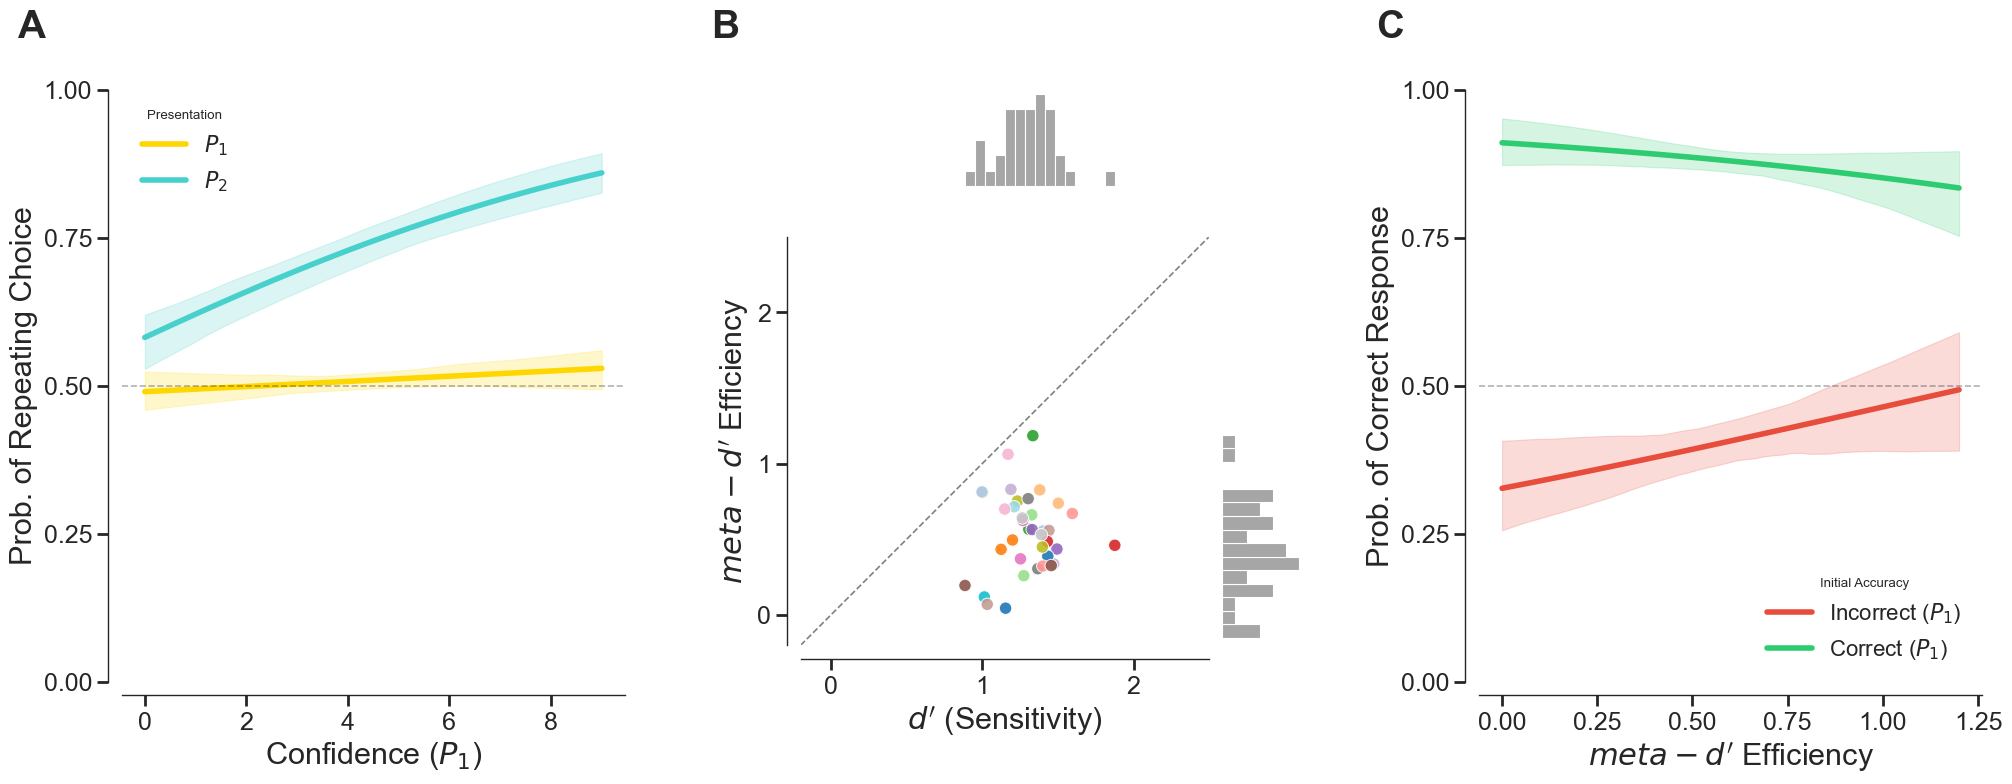

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.transforms as mtransforms
import os  # Added import for path joining

# --- 1. RELOAD DATA ---
final_plot_df = pd.read_csv('./all_data_CSV/plot_CJ_confidence_repeat.csv')
final_summary = pd.read_csv('./all_data_CSV/plot_CJ_metad_repeat.csv')
pred_grid = pd.read_csv('./all_data_CSV/plot_CJ_metad_accuracy.csv')

# --- 2. FIGURE SETUP ---
# FIX 1: Use 'ticks' style instead of 'white' to force tick marks to render
fig = plt.figure(figsize=(24, 8)) 
gs = gridspec.GridSpec(1, 3, wspace=0.35, top=0.85)

# Global Style Settings
LBL_FONT = 22; TIC_FONT = 18; LEG_FONT = 16; PANEL_FONT = 28
y_ticks_prob = [0, 0.25, 0.5, 0.75, 1.0]

# ------------------------------------------------------------------
# PANEL A: Confidence & Choice Consistency
# ------------------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
palette_rep = {'$P_1$': 'gold', '$P_2$': 'mediumturquoise'}
map_rep = {'Initial Presentation': '$P_1$', 'Repeated (Confirmation Bias)': '$P_2$'}

for old_cond, new_label in map_rep.items():
    subset = final_plot_df[final_plot_df['Condition'] == old_cond]
    if not subset.empty:
        ax0.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
                 label=new_label, color=palette_rep[new_label], linewidth=4)
        ax0.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                          color=palette_rep[new_label], alpha=0.2)

ax0.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax0.set_yticks(y_ticks_prob); ax0.set_ylim(0, 1)
ax0.set_xlabel("Confidence ($P_1$)", fontsize=LBL_FONT)
ax0.set_ylabel("Prob. of Repeating Choice", fontsize=LBL_FONT)
ax0.legend(title="Presentation", fontsize=LEG_FONT, frameon=False, loc='upper left')

# ------------------------------------------------------------------
# PANEL B: SDT JOINTPLOT
# ------------------------------------------------------------------
gs_sdt = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], 
                                          width_ratios=[5, 1], height_ratios=[1, 5],
                                          wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs_sdt[1, 0])
ax_marg_x = fig.add_subplot(gs_sdt[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs_sdt[1, 1], sharey=ax_joint)

# Joint Scatter
sns.scatterplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', y='metad_eff', hue='id_subj', 
                palette='tab20', s=80, alpha=0.9, legend=False, ax=ax_joint)

# Marginals
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', color='gray', bins=15, alpha=0.7, ax=ax_marg_x, legend=False)
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], y='metad_eff', color='gray', bins=15, alpha=0.7, ax=ax_marg_y, legend=False)

# Identity line & Aspect
min_val, max_val = -0.2, 2.5
ax_joint.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', zorder=0)
ax_joint.set_aspect('equal')
ax_joint.set_xlim(min_val, max_val); ax_joint.set_ylim(min_val, max_val)

shared_ticks = [0, 1, 2]
ax_joint.set_xticks(shared_ticks); ax_joint.set_yticks(shared_ticks)
ax_joint.set_xlabel("$d'$ (Sensitivity)", fontsize=LBL_FONT)
ax_joint.set_ylabel("$meta-d'$ Efficiency", fontsize=LBL_FONT)

ax_marg_x.axis('off'); ax_marg_y.axis('off') # Clean the marginal histograms

# ------------------------------------------------------------------
# PANEL C: Metacognition & Accuracy
# ------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
colors_acc = {'Incorrect ($P_1$)': '#e74c3c', 'Correct ($P_1$)': '#2ecc71'}
map_acc = {'0': 'Incorrect ($P_1$)', '1': 'Correct ($P_1$)'}

p_grid_filt = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy() if 'nrep' in pred_grid.columns else pred_grid.copy()
label_col = 'Previous_Accuracy' if 'Previous_Accuracy' in p_grid_filt.columns else 'accuracy1'

for old_val, new_label in map_acc.items():
    sub_data = p_grid_filt[p_grid_filt[label_col].astype(str).str.contains(str(old_val))]
    if not sub_data.empty:
        y_col = 'Predicted_Probability' if 'Predicted_Probability' in sub_data.columns else 'Mean_Prob'
        ax3.plot(sub_data['metad_eff'], sub_data[y_col], color=colors_acc[new_label], linewidth=4, label=new_label)
        ax3.fill_between(sub_data['metad_eff'], sub_data['CI_Lower'], sub_data['CI_Upper'], color=colors_acc[new_label], alpha=0.2)

ax3.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax3.set_yticks(y_ticks_prob); ax3.set_ylim(0, 1)
ax3.set_xlabel("$meta-d'$ Efficiency", fontsize=LBL_FONT)
ax3.set_ylabel("Prob. of Correct Response", fontsize=LBL_FONT)
ax3.legend(title="Initial Accuracy", fontsize=LEG_FONT, frameon=False, loc='lower right')

# --- 3. FINAL CLEANUP (SPINES, TICKS, & LABELS) ---

# Apply strict spines and ticks
for ax in [ax0, ax_joint, ax3]:
    sns.despine(ax=ax, offset=10) # Added offset for a cleaner look
    # Force tick marks to render outward and visibly thick
    ax.tick_params(axis='both', which='major', bottom=True, left=True, 
                   direction='out', length=8, width=2, labelsize=TIC_FONT)

# FIX 2: Blended transforms ensure A, B, and C are perfectly level
Y_ALIGN = 0.95 

transA = mtransforms.blended_transform_factory(ax0.transAxes, fig.transFigure)
ax0.text(-0.15, Y_ALIGN, 'A', transform=transA, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transB = mtransforms.blended_transform_factory(ax_joint.transAxes, fig.transFigure)
ax_joint.text(-0.15, Y_ALIGN, 'B', transform=transB, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transC = mtransforms.blended_transform_factory(ax3.transAxes, fig.transFigure)
ax3.text(-0.15, Y_ALIGN, 'C', transform=transC, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

# --- 4. EXPORT TO PDF ---
figpath = os.path.join(figures_path, 'CJ_behavioral_styled.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)
plt.show()

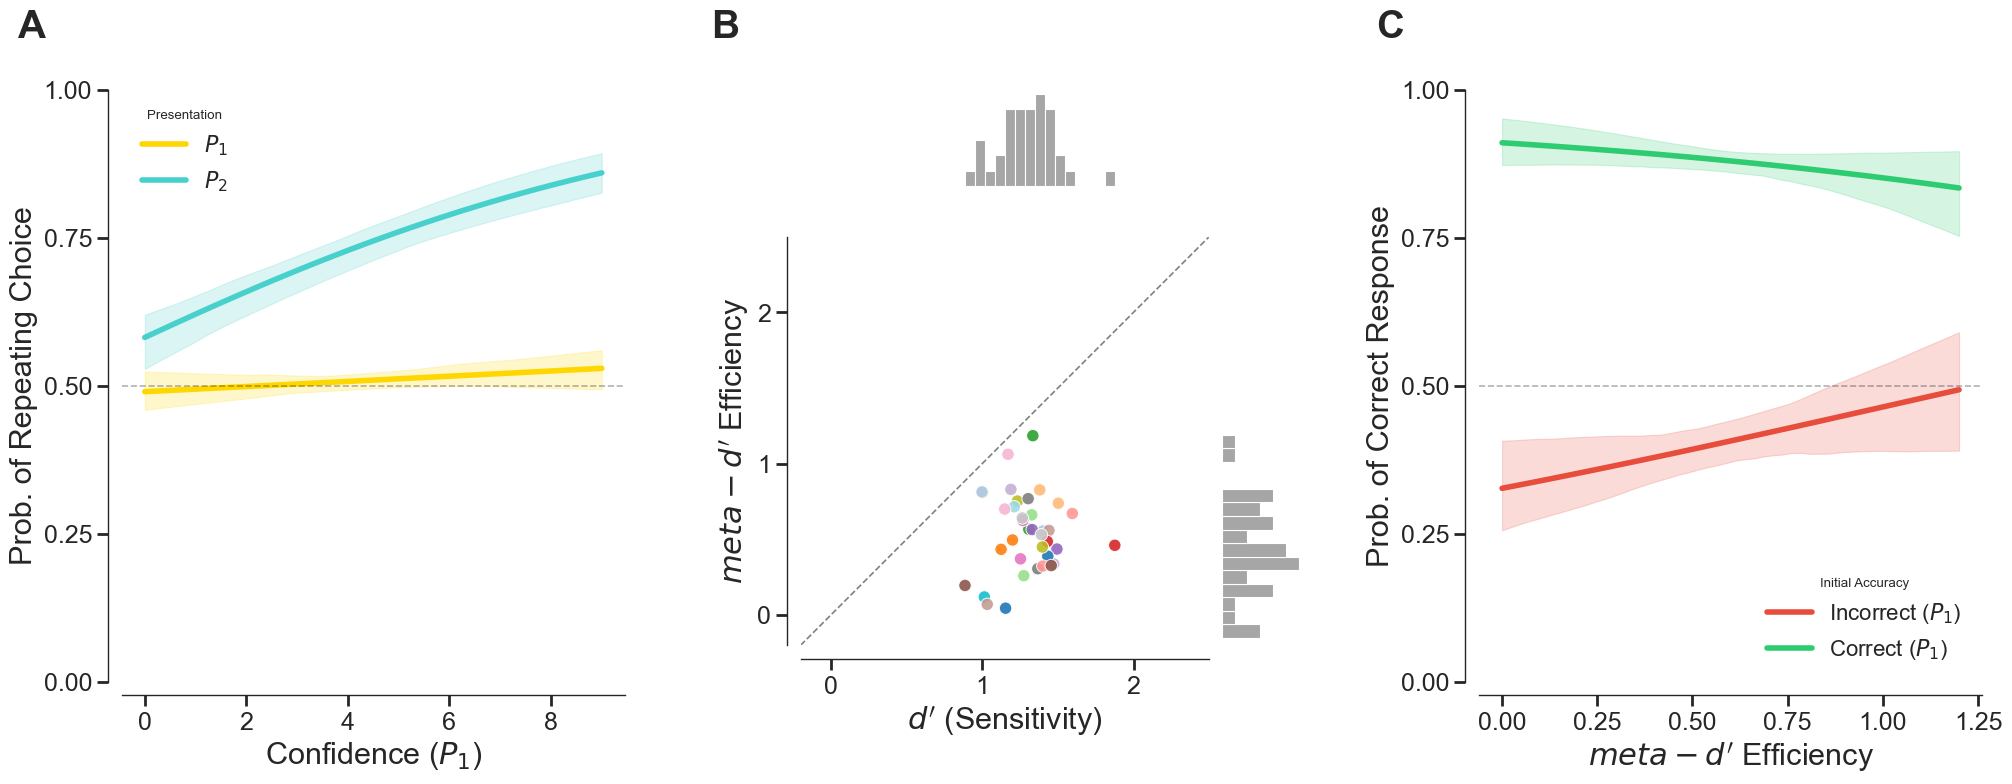

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.transforms as mtransforms
import os  # Added import for path joining

# --- 1. RELOAD DATA ---
final_plot_df = pd.read_csv('./all_data_CSV/plot_CJ_confidence_repeat.csv')
final_summary = pd.read_csv('./all_data_CSV/plot_CJ_metad_repeat.csv')
pred_grid = pd.read_csv('./all_data_CSV/plot_CJ_metad_accuracy.csv')

# --- 2. FIGURE SETUP ---
# FIX 1: Use 'ticks' style instead of 'white' to force tick marks to render
fig = plt.figure(figsize=(24, 8)) 
gs = gridspec.GridSpec(1, 3, wspace=0.35, top=0.85)

# Global Style Settings
LBL_FONT = 22; TIC_FONT = 18; LEG_FONT = 16; PANEL_FONT = 28
y_ticks_prob = [0, 0.25, 0.5, 0.75, 1.0]

# ------------------------------------------------------------------
# PANEL A: Confidence & Choice Consistency
# ------------------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
palette_rep = {'$P_1$': 'gold', '$P_2$': 'mediumturquoise'}
map_rep = {'Initial Presentation': '$P_1$', 'Repeated (Confirmation Bias)': '$P_2$'}

for old_cond, new_label in map_rep.items():
    subset = final_plot_df[final_plot_df['Condition'] == old_cond]
    if not subset.empty:
        ax0.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
                 label=new_label, color=palette_rep[new_label], linewidth=4)
        ax0.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                          color=palette_rep[new_label], alpha=0.2)

ax0.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax0.set_yticks(y_ticks_prob); ax0.set_ylim(0, 1)
ax0.set_xlabel("Confidence ($P_1$)", fontsize=LBL_FONT)
ax0.set_ylabel("Prob. of Repeating Choice", fontsize=LBL_FONT)
ax0.legend(title="Presentation", fontsize=LEG_FONT, frameon=False, loc='upper left')

# ------------------------------------------------------------------
# PANEL B: SDT JOINTPLOT
# ------------------------------------------------------------------
gs_sdt = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], 
                                          width_ratios=[5, 1], height_ratios=[1, 5],
                                          wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs_sdt[1, 0])
ax_marg_x = fig.add_subplot(gs_sdt[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs_sdt[1, 1], sharey=ax_joint)

# Joint Scatter
sns.scatterplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', y='metad_eff', hue='id_subj', 
                palette='tab20', s=80, alpha=0.9, legend=False, ax=ax_joint)

# Marginals
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], x='dprime', color='gray', bins=15, alpha=0.7, ax=ax_marg_x, legend=False)
sns.histplot(data=merged_sdt[merged_sdt.exp_ID == 'CJ'], y='metad_eff', color='gray', bins=15, alpha=0.7, ax=ax_marg_y, legend=False)

# Identity line & Aspect
min_val, max_val = -0.2, 2.5
ax_joint.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', zorder=0)
ax_joint.set_aspect('equal')
ax_joint.set_xlim(min_val, max_val); ax_joint.set_ylim(min_val, max_val)

shared_ticks = [0, 1, 2]
ax_joint.set_xticks(shared_ticks); ax_joint.set_yticks(shared_ticks)
ax_joint.set_xlabel("$d'$ (Sensitivity)", fontsize=LBL_FONT)
ax_joint.set_ylabel("$meta-d'$ Efficiency", fontsize=LBL_FONT)

ax_marg_x.axis('off'); ax_marg_y.axis('off') # Clean the marginal histograms

# ------------------------------------------------------------------
# PANEL C: Metacognition & Accuracy
# ------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
colors_acc = {'Incorrect ($P_1$)': '#e74c3c', 'Correct ($P_1$)': '#2ecc71'}
map_acc = {'0': 'Incorrect ($P_1$)', '1': 'Correct ($P_1$)'}

p_grid_filt = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy() if 'nrep' in pred_grid.columns else pred_grid.copy()
label_col = 'Previous_Accuracy' if 'Previous_Accuracy' in p_grid_filt.columns else 'accuracy1'

for old_val, new_label in map_acc.items():
    sub_data = p_grid_filt[p_grid_filt[label_col].astype(str).str.contains(str(old_val))]
    if not sub_data.empty:
        y_col = 'Predicted_Probability' if 'Predicted_Probability' in sub_data.columns else 'Mean_Prob'
        ax3.plot(sub_data['metad_eff'], sub_data[y_col], color=colors_acc[new_label], linewidth=4, label=new_label)
        ax3.fill_between(sub_data['metad_eff'], sub_data['CI_Lower'], sub_data['CI_Upper'], color=colors_acc[new_label], alpha=0.2)

ax3.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax3.set_yticks(y_ticks_prob); ax3.set_ylim(0, 1)
ax3.set_xlabel("$meta-d'$ Efficiency", fontsize=LBL_FONT)
ax3.set_ylabel("Prob. of Correct Response", fontsize=LBL_FONT)
ax3.legend(title="Initial Accuracy", fontsize=LEG_FONT, frameon=False, loc='lower right')

# --- 3. FINAL CLEANUP (SPINES, TICKS, & LABELS) ---

# Apply strict spines and ticks
for ax in [ax0, ax_joint, ax3]:
    sns.despine(ax=ax, offset=10) # Added offset for a cleaner look
    # Force tick marks to render outward and visibly thick
    ax.tick_params(axis='both', which='major', bottom=True, left=True, 
                   direction='out', length=8, width=2, labelsize=TIC_FONT)

# FIX 2: Blended transforms ensure A, B, and C are perfectly level
Y_ALIGN = 0.95 

transA = mtransforms.blended_transform_factory(ax0.transAxes, fig.transFigure)
ax0.text(-0.15, Y_ALIGN, 'A', transform=transA, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transB = mtransforms.blended_transform_factory(ax_joint.transAxes, fig.transFigure)
ax_joint.text(-0.15, Y_ALIGN, 'B', transform=transB, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

transC = mtransforms.blended_transform_factory(ax3.transAxes, fig.transFigure)
ax3.text(-0.15, Y_ALIGN, 'C', transform=transC, fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

# --- 4. EXPORT TO PDF ---
figpath = os.path.join(figures_path, 'CJ_behavioral_styled.pdf')
plt.savefig(figpath, bbox_inches='tight', dpi=300)
plt.show()

In [321]:
import scipy.stats as stats

# 1. Average across blocktypes to get one value per subject per nrep condition
meta_eff_agg = meta_dprimes.groupby(['subj', 'nrep'])['nrep_metad_eff'].mean().reset_index()

# 2. Pivot the data into wide format (columns for nrep 0 and nrep 1)
eff_wide = meta_eff_agg.pivot(index='subj', columns='nrep', values='nrep_metad_eff').dropna()

# 3. Calculate the Difference (nrep 1 - nrep 0)
eff_wide['difference'] = eff_wide[1] - eff_wide[0]

# Print Mean Difference
mean_diff = eff_wide['difference'].mean()
print(f"Mean Difference (nrep 1 - nrep 0): {mean_diff:.4f}")

# 4. Calculate the Pearson Correlation
corr_r, corr_p = stats.pearsonr(eff_wide[0], eff_wide[1])
print(f"Pearson Correlation: r = {corr_r:.3f}, p = {corr_p:.3f}")

# Optional: Run a paired t-test to see if the difference is statistically significant
t_stat, t_p = stats.ttest_rel(eff_wide[1], eff_wide[0])
print(f"Paired t-test: t = {t_stat:.3f}, p = {t_p:.3f}")


Mean Difference (nrep 1 - nrep 0): -0.0029
Pearson Correlation: r = 0.457, p = 0.006
Paired t-test: t = -0.103, p = 0.918


In [54]:
import scipy.stats as stats

# 1. Pivot the data into wide format, but keep 'blocktype' as part of the index
eff_wide_block = meta_dprimes.pivot_table(
    index=['subj', 'blocktype'], 
    columns='nrep', 
    values='nrep_metad_eff'
).dropna()

# 2. Calculate the Difference (nrep 1 - nrep 0)
eff_wide_block['difference'] = eff_wide_block[1] - eff_wide_block[0]

# 3. Loop through each unique blocktype and calculate the stats
for b_type in eff_wide_block.index.get_level_values('blocktype').unique():
    print(f"\n{'='*40}")
    print(f"  ANALYSIS FOR BLOCKTYPE: {b_type.upper()}")
    print(f"{'='*40}")
    
    # Isolate data just for this specific blocktype
    data_b = eff_wide_block.xs(b_type, level='blocktype')
    
    # Print Mean Difference
    mean_diff = data_b['difference'].mean()
    print(f"Mean Difference (nrep 1 - nrep 0): {mean_diff:.4f}")

    # Calculate the Pearson Correlation
    if len(data_b) > 1: # ensure enough data points
        corr_r, corr_p = stats.pearsonr(data_b[0], data_b[1])
        print(f"Pearson Correlation: r = {corr_r:.3f}, p = {corr_p:.3f}")

        # Run a paired t-test to see if the difference is statistically significant
        t_stat, t_p = stats.ttest_rel(data_b[1], data_b[0])
        print(f"Paired t-test: t = {t_stat:.3f}, p = {t_p:.3f}")
    else:
        print("Not enough data to calculate correlation or t-test.")



  ANALYSIS FOR BLOCKTYPE: NONREPEAT
Mean Difference (nrep 1 - nrep 0): 0.0303
Pearson Correlation: r = 0.379, p = 0.025
Paired t-test: t = 0.729, p = 0.471

  ANALYSIS FOR BLOCKTYPE: REPEAT
Mean Difference (nrep 1 - nrep 0): -0.0361
Pearson Correlation: r = 0.515, p = 0.002
Paired t-test: t = -1.008, p = 0.320


__Two stage regression models__

In [63]:
def log_reg_prevfit(x, f): # this function was used to calculate the log linear regression between two vectors
    x.nrep = np.array(x.nrep)
    reg = smf.glm(formula = f, data = x, family=sm.families.Binomial()).fit()
    params = reg.params
    #PSE = - reg.params.Intercept/reg.params[1]
    # concatenating parameters
    if np.max(x.nrep) == 2:
        out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]], 'intercept2':[params[2]], 'prev0':[params[3]], 'prev1':[params[3] + params[4]], 'prev2':[params[3] + params[5]], 
                            'weight0':[params[6]],'weight1':[params[6] + params[7]],'weight2':[params[6]+ params[8]],'prevweight0':[params[9]],'prevweight1':[params[10]+params[9]],'prevweight2':[params[11]+params[9]]})
    if np.max(x.nrep) == 1:
        out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]],  'prev0':[params[2]], 'prev1':[params[3] + params[2]], 
                            'weight0':[params[4]],'weight1':[params[4] + params[5]],'prevweight0':[params[6]],'prevweight1':[params[6]+params[7]]})
   
    return out #intercept + weight
 

In [64]:
formula = "Responses ~ C(nrep)*C(response1)*dv"
log_regpre_deci_params = dflong.groupby([ 'id_subj','exp_ID']).apply(log_reg_prevfit, formula)
log_regpre_deci_params.reset_index(inplace = True)
log_regpre_deci_params.head()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_7610/309051864.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]], 'intercept2':[params[2]], 'prev0':[params[3]], 'prev1':[params[3] + params[4]], 'prev2':[params[3] + params[5]],
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_7610/309051864.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'weight0':[params[6]],'weight1':[params[6] + params[7]],'weight2':[params[6]+ params[8]],'prevweight0':[params[9]],'prevweight1':[params[10]+params[9]],'prevweight2':[params[11]+params[9

,id_subj,exp_ID,level_2,intercept0,intercept1,intercept2,prev0,prev1,prev2,weight0,weight1,weight2,prevweight0,prevweight1,prevweight2
0,1,3diffs,0,0.273215,-2.591835,-2.997438,-0.014151,4.172037,5.379882,0.872215,0.628230,1.156060,0.004125,0.341573,-0.438025
1,2,3diffs,0,0.423471,-1.722381,-2.410635,0.025533,2.986598,4.175755,0.886938,1.000581,0.690471,-0.036223,0.060712,0.253817
2,3,3diffs,0,0.549506,-0.997848,-1.342415,0.363829,2.089022,2.552093,1.158344,0.647069,0.597360,-0.376940,-0.179236,0.003187
3,4,3diffs,0,0.714806,-1.890327,-2.199547,-0.234305,2.885671,4.375902,0.816864,0.543354,0.750926,-0.077408,0.212446,0.223939
4,5,3diffs,0,0.379008,-1.884463,-1.795698,0.208734,3.077888,3.300579,0.736652,0.529010,0.442309,0.090019,-0.065285,0.142447


In [67]:
from scipy.stats import pearsonr

def perm_test_corr(x, y, n_perm=1000, alpha=0.05):
    """
    Perform a permutation test to assess the significance of the correlation between two variables.
    
    Args:
        x (array-like): First variable.
        y (array-like): Second variable.
        n_perm (int): Number of permutations (default: 1000).
        alpha (float): Significance level (default: 0.05).
    
    Returns:
        tuple: (correlation coefficient, p-value, 95% confidence interval, is_significant)
    """
    # Compute the observed correlation coefficient
    obs_corr, _ = pearsonr(x, y)
    
    # Permute one of the variables and compute correlation coefficients
    corr_perm = []
    for i in range(n_perm):
        perm_y = np.random.permutation(y)
        corr, _ = pearsonr(x, perm_y)
        corr_perm.append(corr)
    
    # Compute the p-value and confidence interval
    corr_perm = np.array(corr_perm)
    p_value = np.sum(np.abs(corr_perm) >= np.abs(obs_corr)) / n_perm
    ci_lower = np.percentile(corr_perm, 2.5)
    ci_upper = np.percentile(corr_perm, 97.5)
    
    # Determine if the correlation is significant
    if p_value < alpha:
        is_significant = True
    else:
        is_significant = False
    
    return obs_corr, p_value, (ci_lower, ci_upper), is_significant

In [42]:
dati = dats[dats.nrep == 1]
# Compute the correlation and assess significance using bootstrap
corr, p_value, ci, sig = perm_test_corr(dati['prevweight'], dati['prev'])

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"95% CI: ({ci[0]:.3f}, {ci[1]:.3f})")
print(f"Significant: {sig}")

NameError: name 'dats' is not defined

In [41]:
indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)
indiv_sdt.reset_index(inplace=True)
merged_sdt = pd.merge( df[df.nrep == 0][['metad', 'id_subj']], indiv_sdt,on = ['id_subj'], how = 'inner') 
merged_sdt.drop_duplicates(subset = ['id_subj'], inplace = True)
merged_sdt['metad_eff'] = merged_sdt['metad'] / merged_sdt['dprime']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_29115/3067209949.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)


Calculating difference in enhancement between 2 and 1 repetition

In [43]:
CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)
CJ_df.reset_index(inplace=True)
CJ_df_diff = CJ_df[CJ_df.nrep == 1].reset_index(drop=True)
aux = CJ_df[CJ_df.nrep == 0].reset_index(drop=True)
CJ_df_diff['diffdprime'] = CJ_df_diff['dprime'] - aux['dprime']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_29115/1710172459.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)


Merging all the CJ dataframes

In [44]:
group_repeat_correct = df.groupby(['exp_ID', 'id_subj','nrep', 'accuracy','metad_eff'],as_index=False)[['RepResponses']].mean()

In [45]:
df_cj = df[df['exp_ID'] == 'CJ'].copy() # Create a separate DataFrame for CJ to avoid modifying the original
group_repeat_correct = df_cj.groupby(['id_subj','nrep', 'accuracy1'], as_index=False)[['RepResponses']].mean()
group_repeat_correct
group_repeat_metadeff = df_cj.groupby(['id_subj','nrep', 'accuracy1'], as_index=False)[['metad_eff']].mean()

group_repeat_correct['metad_eff'] = group_repeat_metadeff['metad_eff']

group_repeat_correct

,id_subj,nrep,accuracy1,RepResponses,metad_eff
0,107,0,0,0.500000,0.045045
1,107,0,1,0.540323,0.045045
2,107,1,0,0.549020,0.045045
3,107,1,1,0.816000,0.045045
4,108,0,0,0.536585,0.555141
...,...,...,...,...,...
143,142,1,1,0.888889,0.530481
144,143,0,0,0.571429,0.449383
145,143,0,1,0.388060,0.449383
146,143,1,0,0.708333,0.449383


Plotting the interaction

In [140]:
from pymer4 import Lmer

In [141]:
dat = df[(df.exp_ID == '3reps')]

md_3reps_full_confi_exp = Lmer("Responses ~  rDV  * response1 * rtconf1 * nrep + (1|id_subj)", data= dat, family="binomial")
md_3reps_full_confi_exp.fit(factors = {"nrep": ['0','1','2']})
#lmm_models['CJ_exp']['md_CJ_full_confi_exp'] = md_CJ_full_confi_exp

/Users/alex/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "SideResp1". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*rtconf1*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 19440	 Groups: {'id_subj': 27.0}

Log-likelihood: -8566.580 	 AIC: 17183.160

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.079  0.281

No random effect correlations specified

Fixed effects:



/Users/alex/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.472,0.331,0.613,0.072,1.603,1.392,1.846,0.616,0.582,0.649,6.557,0.000,***
rDV,2.899,2.612,3.187,0.147,18.162,13.628,24.206,0.948,0.932,0.960,19.783,0.000,***
response1,0.206,0.085,0.327,0.062,1.229,1.089,1.386,0.551,0.521,0.581,3.349,0.001,***
rtconf1,-0.046,-0.146,0.053,0.051,0.955,0.865,1.055,0.488,0.464,0.513,-0.912,0.362,
nrep1,-1.572,-1.717,-1.426,0.074,0.208,0.180,0.240,0.172,0.152,0.194,-21.181,0.000,***
nrep2,-1.752,-1.898,-1.606,0.074,0.173,0.150,0.201,0.148,0.130,0.167,-23.564,0.000,***
rDV:response1,0.268,-0.109,0.645,0.192,1.308,0.897,1.906,0.567,0.473,0.656,1.395,0.163,
rDV:rtconf1,-0.099,-0.382,0.185,0.145,0.906,0.682,1.203,0.475,0.406,0.546,-0.682,0.495,
response1:rtconf1,-0.011,-0.139,0.118,0.066,0.989,0.870,1.125,0.497,0.465,0.529,-0.162,0.871,
rDV:nrep1,-0.885,-1.329,-0.442,0.226,0.413,0.265,0.643,0.292,0.209,0.391,-3.916,0.000,***


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1383679061.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


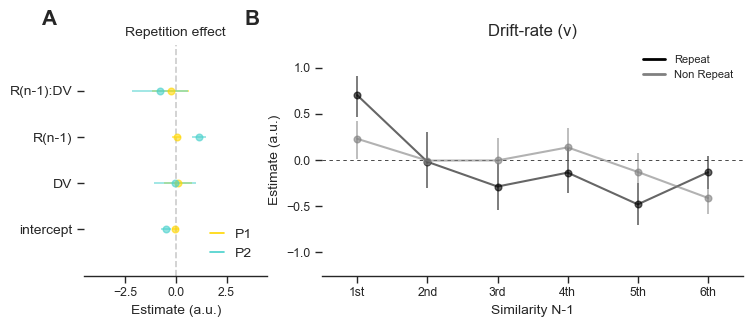

In [46]:


colpal4 = ['black', 'grey']
EXP = 'CJ'
labels = ['P1', 'P2']

# Set up the figure and GridSpec (First row only)
fig = plt.figure(figsize=(8.5, 3))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.3)

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])    # This subplot spans the first column
ax2 = fig.add_subplot(gs[0, 1:3])  # This subplot spans the second and third columns

# =================================================================
# Panel A: REPETITION EFFECT (ax1)
# =================================================================
estims = organize_data_param(lmm_models['CJ_exp']['md_CJ_rep_exp'].coefs, 1, 'trial_typerepeat')
estims['nrep'] = estims['nrep'].astype(int)
nreps = np.unique(estims['nrep'])

plot_params = [p for p in estims['parameter'].unique() if p not in ['bias', 'weight']]
lab_names = ['intercept', 'DV', 'R(n-1)', 'R(n-1):DV']

for y_idx, yrep in enumerate(nreps):
    stim = estims[(estims.nrep == yrep) & (estims.parameter.isin(plot_params))].copy()
    
    # Exact original coordinates (No dodging)
    x_vals = stim['Estimate'].values
    y_pos = np.arange(len(stim['parameter'].unique())) 
    
    # Exact original error calculation: np.abs(stim[["2.5_ci", "97.5_ci"]].T - stim['Estimate'])
    errs_raw = np.array(stim[["2.5_ci", "97.5_ci"]]).T
    x_err = np.abs(errs_raw - x_vals)
    
    # Plot points and error bars
    ax1.plot(x_vals, y_pos, marker='o', ls='', color=colpal2[y_idx], alpha=0.6, zorder=4)
    ax1.errorbar(x_vals, y_pos, xerr=x_err, fmt=' ', ecolor=colpal2[y_idx], alpha=0.6, zorder=3)
    
    # Dummy plot for clean legend generation
    ax1.plot([], [], color=colpal2[y_idx], label=labels[yrep])

# ADDED 'handlelength=1.0' HERE to make the lines shorter
ax1.legend(loc='lower right', borderpad=0.6, prop={'size': 10}, framealpha=0.0, handlelength=1.0)
ax1.set_title('Repetition effect', fontsize=10)

ax1.axvline(0.0, ls='--', color='black', alpha=0.2)
ax1.set_yticks(np.arange(len(plot_params)))
ax1.set_yticklabels(lab_names, fontsize=10)
ax1.set_ylabel('')
ax1.set_xlim([-4.5, 4.5])
ax1.set_ylim([-1, 4])
ax1.set_xlabel('Estimate (a.u.)', fontsize=10)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# =================================================================
# Panel B: DDM REPEAT EFFECTS (ax2)
# =================================================================
models = ['stimcoding_diff_prev_repeat', 'stimcoding_diff_prev_nonrepeat']
y_limits = [-1.25, 1.25]
estims_ddm = params_reg[params_reg.exp == EXP].copy()

for col in ['mean', '2.5q', '97.5q']:
    estims_ddm[col] = estims_ddm[col].astype(float)

for y_idx, ymodel in enumerate(models):
    stims = estims_ddm[(estims_ddm.param == 'v') & (estims_ddm.model == ymodel)].copy()
    
    # Align condition 0 and 1
    stim_1 = stims[stims.nrep == 1].sort_values('pos').reset_index(drop=True)
    stim_0 = stims[stims.nrep == 0].sort_values('pos').reset_index(drop=True)
    
    # Exact original math: difference of means
    y_vals = stim_1['mean'].values - stim_0['mean'].values
    
    # Exact original coordinates (No dodging)
    x_pos = np.arange(len(stim_1['pos'].unique()))
    
    # Exact original error calculation: raw quantiles directly as magnitudes
    errs_raw = np.array(stim_1[["2.5q", "97.5q"]]).T
    y_err = np.abs(errs_raw)
    
    # Plot line (join=True emulation) and errorbars
    ax2.plot(x_pos, y_vals, marker='o', color=colpal4[y_idx], alpha=0.6, lw=1.5, zorder=4)
    ax2.errorbar(x_pos, y_vals, yerr=y_err, fmt=' ', ecolor=colpal4[y_idx], alpha=0.6, zorder=3)

ax2.set_title('Drift-rate (v)', fontsize=12)

ax2.axhline(0, color='black', lw=0.5, ls='--', dashes=(5, 5))
ax2.set_ylim(y_limits)
ax2.set_xlim([-0.5, 5.5])
ax2.set_xticks(np.arange(6))
ax2.set_xticklabels(['1st', '2nd', '3rd', '4th', '5th', '6th'])
ax2.set_xlabel('Similarity N-1', fontsize=10)
ax2.set_ylabel('Estimate (a.u.)', fontsize=10)

legend_labels = ['Repeat', 'Non Repeat']
lines = [Line2D([0], [0], color=c, lw=2) for c in colpal4]
ax2.legend(lines, legend_labels, loc='upper right', fontsize=8, framealpha=0.0)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# =================================================================
# ETIQUETADO DE PANELES (A, B)
# =================================================================
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate([ax1, ax2]):
    ax.text(-0.15, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

# Simulated data

In [20]:
# Specify the filename from where you want to load the pickle file
csv_file =  results_path + 'Group_level_analyses/sim_data/all_simdata.csv'
# Open the file in binary read mode and load the data from it
all_data = pd.read_csv(csv_file)
# Now 'loaded_data' contains the data that was stored in the pickle file

# Specify the filename from where you want to load the pickle file
csv_file =  results_path + 'Group_level_analyses/sim_data/all_sims.csv'
# Open the file in binary read mode and load the data from it
all_params  = pd.read_csv(csv_file)

__Loading DDMs params__

In [21]:
params_path = os.path.join(hddm_m_path,  'DDMs_params.csv')  
ddms_params = pd.read_csv(params_path)
ddms_params['fitted'] = 'real'
ddms_params.loc[ddms_params['exp_ID'].isin(['threshold_sim', 'lapse_sim', 'Z_sim','slope_sim']), 'fitted'] = 'simul'

 #  Preparing data

In [22]:
# recoding variables
all_data.rename(columns= {'deci' : 'Responses', 'RT' : 'rt', 'stim':'Stimuli'}, inplace=True)
all_data.loc[all_data['Stimuli'] == -1, 'Stimuli'] = 0

all_data['nrep'] = all_data['nrep'].astype('int')
all_data['pre_deci'] = all_data['pre_deci'].astype('int')
all_data['nit'] = all_data['nit'].astype('category')

In [23]:
group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)
group_sdt_avg.reset_index(inplace=True)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3900049082.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3900049082.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)


In [25]:
modelfit = ddms_params.groupby(['exp_ID', 'model','fitted'], as_index=False)[['aic','bic']].mean()

level_mapping = {
    'nohist' : 'no hist',
    'stimcoding_nohist' : 'no hist',
    'Z' : 'z', 
    'stimcoding_z_prevresp' : 'z',
    'dc': 'dc', 
    'stimcoding_dc_prevresp': 'dc',   
    'stimcoding_zXdc_prevresp' : 'zXdc',
    'stimcoding_dc_prevresp_trial_type' : 'zXdcrepeat'    
}


In [26]:
# Use the replace() method to rename the levels
modelfit['model'] = modelfit['model'].replace(level_mapping)
modelfit['model'] = modelfit['model'].astype('category')
# Reorder categories and assign the result back
modelfit['model'] = modelfit['model'].cat.reorder_categories(['no hist','z','dc','zXdc','zXdcrepeat'])

In [27]:
# Filter data where 'fitted' column is 'sim'
modelsim = modelfit[modelfit['fitted'] == 'simul']

# Remove unused categories from 'model' column (assuming it's categorical)
modelsim['model'] = modelsim['model'].cat.remove_unused_categories()


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/1100228519.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modelsim['model'] = modelsim['model'].cat.remove_unused_categories()


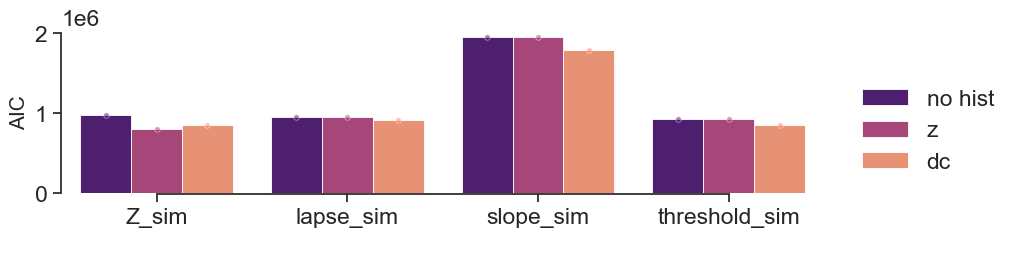

In [29]:

dat = modelsim.copy()
sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] =3
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'AIC'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'exp_ID'; dy = 'bic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

Creating individual IDs for each participant (to prevent modelling taking different subjects with similar names as identical)

In [31]:
import seaborn as sns

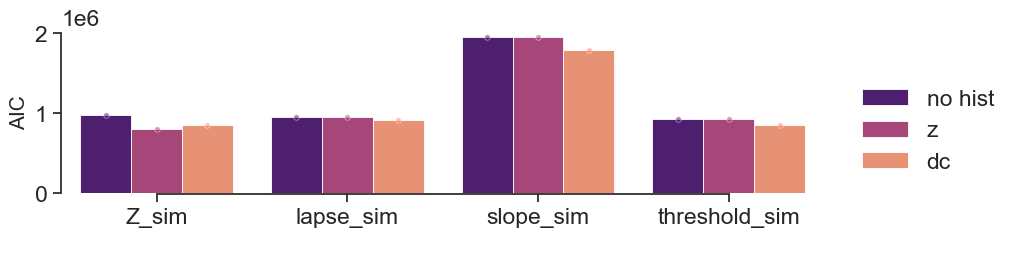

In [30]:
dat = modelsim.copy()
sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] =3
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'AIC'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'exp_ID'; dy = 'bic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

modelsim = ddms_params.groupby(['exp_ID','model'])[['aic','bic']].mean()
modelsim.reset_index(inplace=True)

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (

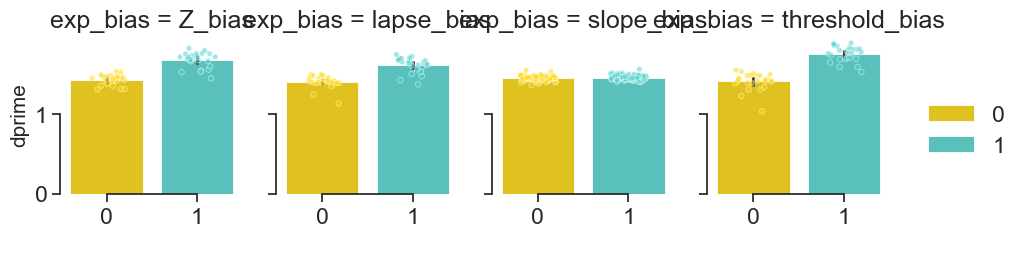

In [32]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'dprime'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'nrep'; dy = 'dprime'; hue = 'nrep';  row = None; col = 'exp_bias'
pal = colpal2

barsplot(group_sdt_avg, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


_Lapse model_

In [33]:
# Based on your screenshot, these are likely:
id_vars = ['niter', 'nrep', 'pre_deci', 'model']

# Specify the columns whose values you want to stack
value_vars = ['intercept', 'DV']

params_stacked = pd.melt(
    all_params,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='parameter',     # The new column indicating the original variable name
    value_name='Estimate'  # The new column holding the values (using 'Estimate' as seen in your previous code)
)

grouped_params = params_stacked.groupby([ 'model', 'nrep',  'pre_deci', 'parameter'], as_index=False)[['Estimate']].agg(
    Estimate=('Estimate', 'mean'),  # Calculate the mean and name the output column 'mean_estimate'
    sem=('Estimate', sem)       # Calculate the Standard Error and name the output column 'se_estimate'
    # You could also add 'count', 'std', etc. here if needed
    # count_obs=('Estimate', 'size')
    # std_dev=('Estimate', 'std')
)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2200575529.py:58: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2200575529.py:60: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2200575529.py:76: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/2200575529.py:78: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


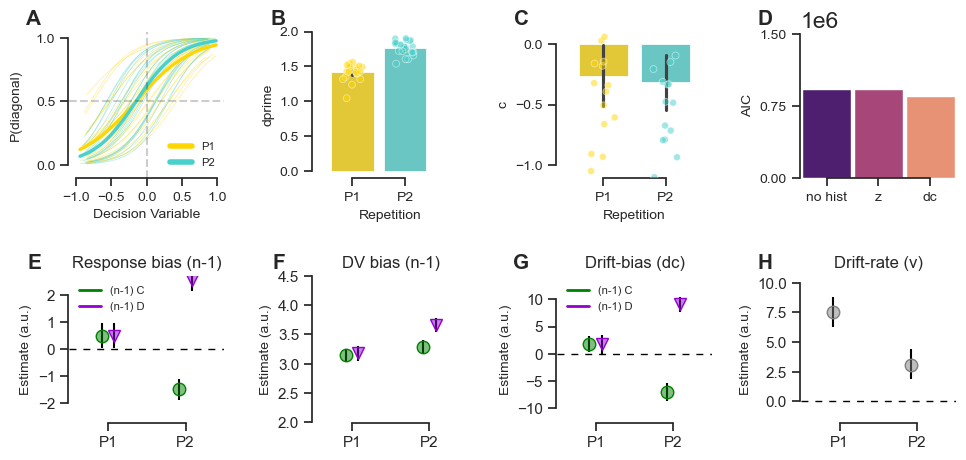

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import string

EXP = 'threshold_bias'
EXP_ddm = 'threshold_sim'
best_model = 'dc'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel [0,0]: Psychometric function ──────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)
axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_yticks([0.0, 0.5, 1]); axes[axis].set_ylim(-0.1, 1.05)
axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)
# Legend with Line2D objects (matching second figure style)
axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel [0,1]: d-prime ─────────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)
axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel [0,2]: criterion c ──────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)
axes[axis].set_ylabel("c", fontsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel [0,3]: Model comparison (AIC) ──────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)
axes[axis].set_ylim(0., 1.53e6); axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels [1,0] and [1,1]: Psychophysics regression parameters ───────────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

y_limits   = [[-2.7, 2.7], [2, 4.5]]
sp_titles  = ['Response bias (n-1)', 'DV bias (n-1)']
dodge_small = 0.08

for i, iparam in enumerate(['intercept', 'DV']):
    axis = (1, i)
    ax   = axes[axis]
    ax.set_title(sp_titles[i], fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          # hue levels

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if i == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(y_limits[i])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels [1,2] and [1,3]: DDM parameters ───────────────────────────────────
y_limits  = [[-0.0, 10], [-0.5, 1]]
sp_titles = ['Drift-bias (dc)', 'Drift-rate (v)']
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

dodge_small = 0.08

for j, jparam in enumerate(['dc', 'v']):
    axis = (1, 2 + j)
    ax   = axes[axis]
    ax.set_title(sp_titles[j], fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # --- APPLIED GREY FOR DRIFT RATE ---
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if j == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1281107833.py:54: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1281107833.py:56: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1281107833.py:75: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/1281107833.py:77: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


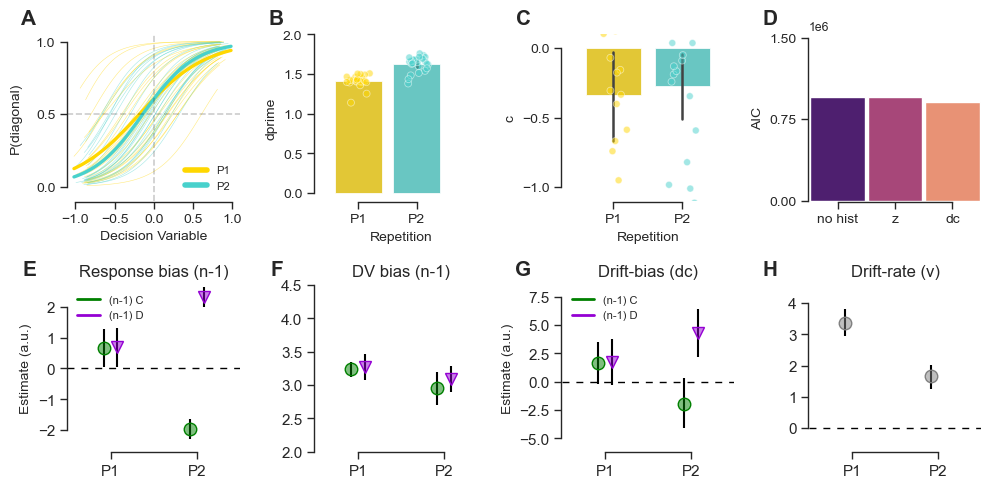

In [67]:


EXP = 'lapse_bias'
EXP_ddm = 'lapse_sim'
best_model = 'dc'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel A [0,0]: Psychometric function ─────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)

# Exact limits from your provided code
axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_ylim(-0.1, 1.05); axes[axis].set_yticks([0.0, 0.5, 1])

axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)

axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel B [0,1]: d-prime ───────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel C [0,2]: criterion c ────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("c", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel D [0,3]: Model comparison (AIC) ────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(0., 1.53e6); axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels E & F [1,0] and [1,1]: Psychophysics regression parameters ─────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

# Exact limits from your provided code
y_limits   = [[-2.7, 2.7], [2, 4.5]]
sp_titles  = ['Response bias (n-1)', 'DV bias (n-1)']
dodge_small = 0.08

for i, iparam in enumerate(['intercept', 'DV']):
    axis = (1, i)
    ax   = axes[axis]
    ax.set_title(sp_titles[i], fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if i == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(y_limits[i])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if i == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels G & H [1,2] and [1,3]: DDM parameters ──────────────────────────────
# Exact limits from your provided code
y_limits  = [[-0.0, 10], [-0.5, 1]]
sp_titles = ['Drift-bias (dc)', 'Drift-rate (v)']
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

dodge_small = 0.08

for j, jparam in enumerate(['dc', 'v']):
    axis = (1, 2 + j)
    ax   = axes[axis]
    ax.set_title(sp_titles[j], fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # Apply GREY explicitly for drift rate 'v'
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if j == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    #ax.set_ylim(y_limits[j])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if j == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3696331560.py:53: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3696331560.py:55: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3696331560.py:73: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_31949/3696331560.py:75: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


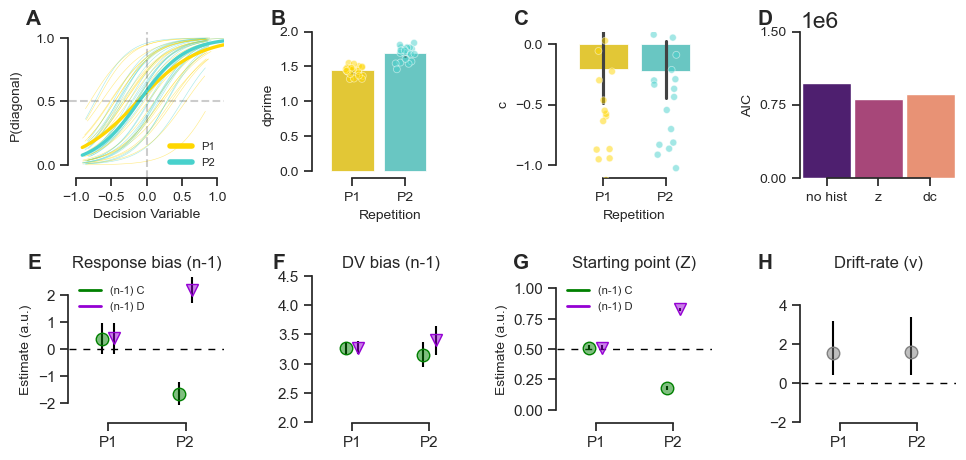

In [35]:

EXP = 'Z_bias'
EXP_ddm = 'Z_sim'
best_model = 'Z'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel A [0,0]: Psychometric function ─────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)

axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_ylim(-0.1, 1.05); axes[axis].set_yticks([0.0, 0.5, 1])

axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)

axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel B [0,1]: d-prime ───────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel C [0,2]: criterion c ────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("c", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel D [0,3]: Model comparison (AIC) ────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)

axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels E & F [1,0] and [1,1]: Psychophysics regression parameters ─────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

psy_params = [
    ('intercept', 'Response bias (n-1)', 0, [-2.7, 2.7]), 
    ('DV', 'DV bias (n-1)', 1, [2, 4.5])
]
dodge_small = 0.08

for iparam, title, col_idx, ylims in psy_params:
    axis = (1, col_idx)
    ax   = axes[axis]
    ax.set_title(title, fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if col_idx == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(ylims)
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if col_idx == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels G & H [1,2] and [1,3]: DDM parameters ──────────────────────────────
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

# DDM setup mapping jparam, title, column_index, ylims, and ab_line
ddm_params = [
    ('z', 'Starting point (Z)', 2, [-0.1, 1.1], 0.5), 
    ('v', 'Drift-rate (v)',     3, [-2, 5.5],   0.0)
]
dodge_small = 0.08

for jparam, title, col_idx, ylims, ab_line in ddm_params:
    axis = (1, col_idx)
    ax   = axes[axis]
    ax.set_title(title, fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    # Apply the specific horizontal reference line for this parameter
    ax.axhline(y=ab_line, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # Apply GREY explicitly for drift rate 'v'
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if col_idx == 2:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(ylims)
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if col_idx == 2 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

__Functions__

In [71]:
def sinusoidal_function(x, min_amp, max_amp, frequency_hz, phase_shift):
    omega = 2 * np.pi * frequency_hz
    amplitude = (max_amp - min_amp) / 2
    offset = (max_amp + min_amp) / 2
    return amplitude * np.sin(omega * x + phase_shift) + offset


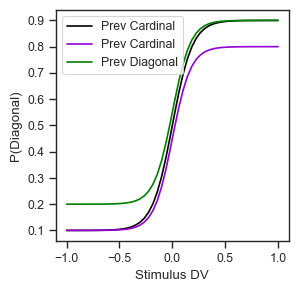

In [75]:
# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10)* (x - threshold))))
    return prob

threshold = -0.0 # Threshold for detecting the stimulus
slope = 0.5  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity


# Visualize the probabilities of discriminating C vs D
prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_D = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low+ 0.1, lapse_high )
prob_detect_C = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low , lapse_high+ 0.1)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect, 'black', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_C,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_D,'green', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

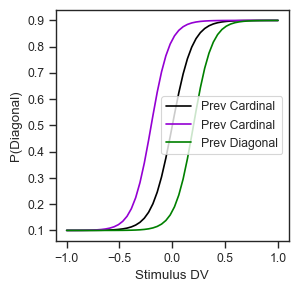

In [76]:
# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10)* (x - threshold))))
    return prob

threshold = -0.0 # Threshold for detecting the stimulus
slope = 0.5  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity


# Visualize the probabilities of discriminating C vs D
prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_D = psychometric_function(stimulus_intensities, threshold + 0.2, slope + 1, lapse_low, lapse_high)
prob_detect_C = psychometric_function(stimulus_intensities, threshold - 0.2, slope + 1, lapse_low , lapse_high)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect, 'black', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_C,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_D,'green', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

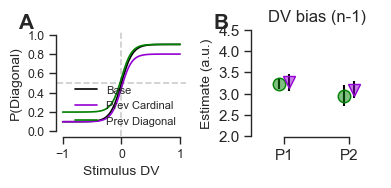

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import string

# --- Assuming these are pre-loaded in your environment ---
# grouped_params, colpal3

# --- 1. PREPARE FIGURE (1 Row, 2 Columns) ---
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
fig.subplots_adjust(wspace=0.3)

# =================================================================
# PANEL A [Left]: Psychometric Function with Lapses
# =================================================================
ax0 = axes[0]

def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10)* (x - threshold))))
    return prob

threshold = -0.0  
slope = 0.5       
lapse_low = 0.1   
lapse_high = 0.1  

# Generate x-values (assuming a typical DV range from -1 to 1)
stimulus_intensities = np.linspace(-1, 1, 100)

prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_D = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low + 0.1, lapse_high)
prob_detect_C = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low, lapse_high + 0.1)

# Plotting the curves
ax0.plot(stimulus_intensities, prob_detect, color='black', label='Base') # Adjusted label for clarity
ax0.plot(stimulus_intensities, prob_detect_C, color='darkviolet', label='Prev Cardinal')
ax0.plot(stimulus_intensities, prob_detect_D, color='green', label='Prev Diagonal')

# Formatting Panel A
ax0.axvline(0, ls='--', color='black', alpha=0.2)
ax0.axhline(0.5, ls='--', color='black', alpha=0.2)
ax0.set_xlabel('Stimulus DV', fontsize=10)
ax0.set_ylabel('P(Diagonal)', fontsize=10)
ax0.set_ylim(-0.05, 1.05)
ax0.legend(loc='lower right', fontsize=8, framealpha=0.0)
sns.despine(ax=ax0, trim=True, offset=0.5)


# =================================================================
# PANEL B [Right]: DV bias (n-1) (Originally Panel F)
# =================================================================
ax1 = axes[1]
EXP = 'lapse_bias'
dodge_small = 0.08

# Prepare the data
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

# Filter specifically for the 'DV' parameter (Panel F)
stim = estims[estims.parameter == 'DV']
prev_vals = np.unique(stim['pre_deci'])          

ax1.set_title('DV bias (n-1)', fontsize=12)
ax1.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

# Plot the estimates
for h_idx, h_val in enumerate(prev_vals):
    subset = stim[stim['pre_deci'] == h_val].sort_values('nrep')
    nreps = np.unique(stim['nrep'])
    
    # Calculate dodged x-positions
    x_pos = np.arange(len(nreps)) + (dodge_small if h_idx == 1 else -dodge_small)

    y_vals = subset['Estimate'].values
    yerr = [np.abs(y_vals - subset['2.5_ci'].values),
            np.abs(subset['97.5_ci'].values - y_vals)]

    base_col = colpal3[h_idx]
    face_col = mcolors.to_rgba(base_col, alpha=0.5)
    marker = 'o' if h_idx == 0 else 'v'

    ax1.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                 color=base_col, mfc=face_col, mec=base_col,
                 markersize=9, elinewidth=1.5, ecolor='black',
                 capsize=0, zorder=10)

# Formatting Panel B
ax1.set_ylim([2, 4.5]) # Kept your exact limits for Panel F
ax1.set_ylabel('Estimate (a.u.)', fontsize=10)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['P1', 'P2'])
ax1.set_xlim([-0.5, 1.5])
ax1.margins(x=0.2, y=0.2)
ax1.set_xlabel('', fontsize=0)
ax1.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax1, offset=0.5, trim=True)


# =================================================================
# ETIQUETADO DE PANELES (A, B)
# =================================================================
panel_labels = ['A', 'B']
for idx, ax in enumerate(axes):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

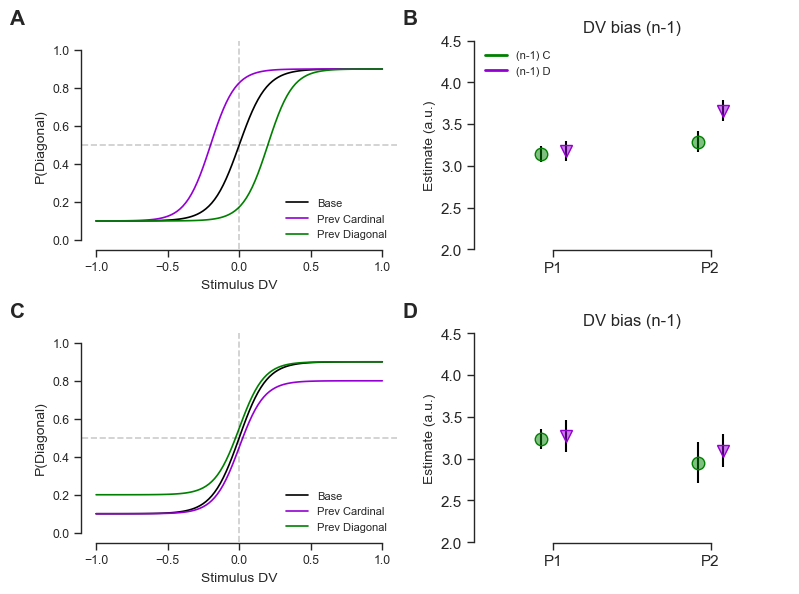

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import string

# --- 1. PREPARE FIGURE (2 Rows, 2 Columns) ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
fig.subplots_adjust(wspace=0.3, hspace=0.5)

stimulus_intensities = np.linspace(-1, 1, 100)

def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10) * (x - threshold))))
    return prob

threshold = -0.0
slope = 0.5
lapse_low = 0.1
lapse_high = 0.1
dodge_small = 0.08

# =================================================================
# PANEL A [0,0]: Psychometric Function with Threshold Shifts
# =================================================================
ax0 = axes[0, 0]

prob_detect2   = psychometric_function(stimulus_intensities, threshold,       slope,     lapse_low, lapse_high)
prob_detect2_D = psychometric_function(stimulus_intensities, threshold + 0.2, slope + 1, lapse_low, lapse_high)
prob_detect2_C = psychometric_function(stimulus_intensities, threshold - 0.2, slope + 1, lapse_low, lapse_high)

ax0.plot(stimulus_intensities, prob_detect2,   color='black',      label='Base')
ax0.plot(stimulus_intensities, prob_detect2_C, color='darkviolet', label='Prev Cardinal')
ax0.plot(stimulus_intensities, prob_detect2_D, color='green',      label='Prev Diagonal')

ax0.axvline(0, ls='--', color='black', alpha=0.2)
ax0.axhline(0.5, ls='--', color='black', alpha=0.2)
ax0.set_xlabel('Stimulus DV', fontsize=10)
ax0.set_ylabel('P(Diagonal)', fontsize=10)
ax0.set_ylim(-0.05, 1.05)
ax0.legend(loc='lower right', fontsize=8, framealpha=0.0)
sns.despine(ax=ax0, trim=True, offset=0.5)

# =================================================================
# PANEL B [0,1]: DV bias (n-1) — threshold_bias model
# =================================================================
ax1 = axes[0, 1]
EXP_thresh = 'threshold_bias'

estims_thresh = grouped_params[grouped_params.model == EXP_thresh].copy()
estims_thresh["2.5_ci"]  = estims_thresh["Estimate"] - estims_thresh["sem"] * 1.96
estims_thresh["97.5_ci"] = estims_thresh["Estimate"] + estims_thresh["sem"] * 1.96

stim2      = estims_thresh[estims_thresh.parameter == 'DV']
prev_vals2 = np.unique(stim2['pre_deci'])

ax1.set_title('DV bias (n-1)', fontsize=12)
ax1.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

for h_idx, h_val in enumerate(prev_vals2):
    subset  = stim2[stim2['pre_deci'] == h_val].sort_values('nrep')
    nreps   = np.unique(stim2['nrep'])
    x_pos   = np.arange(len(nreps)) + (dodge_small if h_idx == 1 else -dodge_small)
    y_vals  = subset['Estimate'].values
    yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
               np.abs(subset['97.5_ci'].values - y_vals)]
    base_col = colpal3[h_idx]
    face_col = mcolors.to_rgba(base_col, alpha=0.5)
    marker   = 'o' if h_idx == 0 else 'v'
    ax1.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                 color=base_col, mfc=face_col, mec=base_col,
                 markersize=9, elinewidth=1.5, ecolor='black',
                 capsize=0, zorder=10)

ax1.legend(
    [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals2))],
    ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

ax1.set_ylim([2, 4.5])
ax1.set_ylabel('Estimate (a.u.)', fontsize=10)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['P1', 'P2'])
ax1.set_xlim([-0.5, 1.5])
ax1.margins(x=0.2, y=0.2)
ax1.set_xlabel('', fontsize=0)
ax1.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax1, offset=0.5, trim=True)


# =================================================================
# PANEL C [1,0]: Psychometric Function with Lapses
# =================================================================
ax2 = axes[1, 0]

prob_detect   = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_D = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low + 0.1, lapse_high)
prob_detect_C = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low, lapse_high + 0.1)

ax2.plot(stimulus_intensities, prob_detect,   color='black',      label='Base')
ax2.plot(stimulus_intensities, prob_detect_C, color='darkviolet', label='Prev Cardinal')
ax2.plot(stimulus_intensities, prob_detect_D, color='green',      label='Prev Diagonal')

ax2.axvline(0, ls='--', color='black', alpha=0.2)
ax2.axhline(0.5, ls='--', color='black', alpha=0.2)
ax2.set_xlabel('Stimulus DV', fontsize=10)
ax2.set_ylabel('P(Diagonal)', fontsize=10)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='lower right', fontsize=8, framealpha=0.0)
sns.despine(ax=ax2, trim=True, offset=0.5)


# =================================================================
# PANEL D [1,1]: DV bias (n-1) — lapse_bias model
# =================================================================
ax3 = axes[1, 1]
EXP_lapse = 'lapse_bias'

estims_lapse = grouped_params[grouped_params.model == EXP_lapse].copy()
estims_lapse["2.5_ci"]  = estims_lapse["Estimate"] - estims_lapse["sem"] * 1.96
estims_lapse["97.5_ci"] = estims_lapse["Estimate"] + estims_lapse["sem"] * 1.96

stim = estims_lapse[estims_lapse.parameter == 'DV']
prev_vals = np.unique(stim['pre_deci'])

ax3.set_title('DV bias (n-1)', fontsize=12)
ax3.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

for h_idx, h_val in enumerate(prev_vals):
    subset = stim[stim['pre_deci'] == h_val].sort_values('nrep')
    nreps  = np.unique(stim['nrep'])
    x_pos  = np.arange(len(nreps)) + (dodge_small if h_idx == 1 else -dodge_small)
    y_vals = subset['Estimate'].values
    yerr   = [np.abs(y_vals - subset['2.5_ci'].values),
              np.abs(subset['97.5_ci'].values - y_vals)]
    base_col = colpal3[h_idx]
    face_col = mcolors.to_rgba(base_col, alpha=0.5)
    marker   = 'o' if h_idx == 0 else 'v'
    ax3.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                 color=base_col, mfc=face_col, mec=base_col,
                 markersize=9, elinewidth=1.5, ecolor='black',
                 capsize=0, zorder=10)

ax3.set_ylim([2, 4.5])
ax3.set_ylabel('Estimate (a.u.)', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['P1', 'P2'])
ax3.set_xlim([-0.5, 1.5])
ax3.margins(x=0.2, y=0.2)
ax3.set_xlabel('', fontsize=0)
ax3.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax3, offset=0.5, trim=True)

# =================================================================
# PANEL LABELS (A, B, C, D)
# =================================================================
panel_labels = ['A', 'B', 'C', 'D']
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/2603216453.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend(loc='best', fontsize=0, framealpha=0.0)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18519/2603216453.py:332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=2)


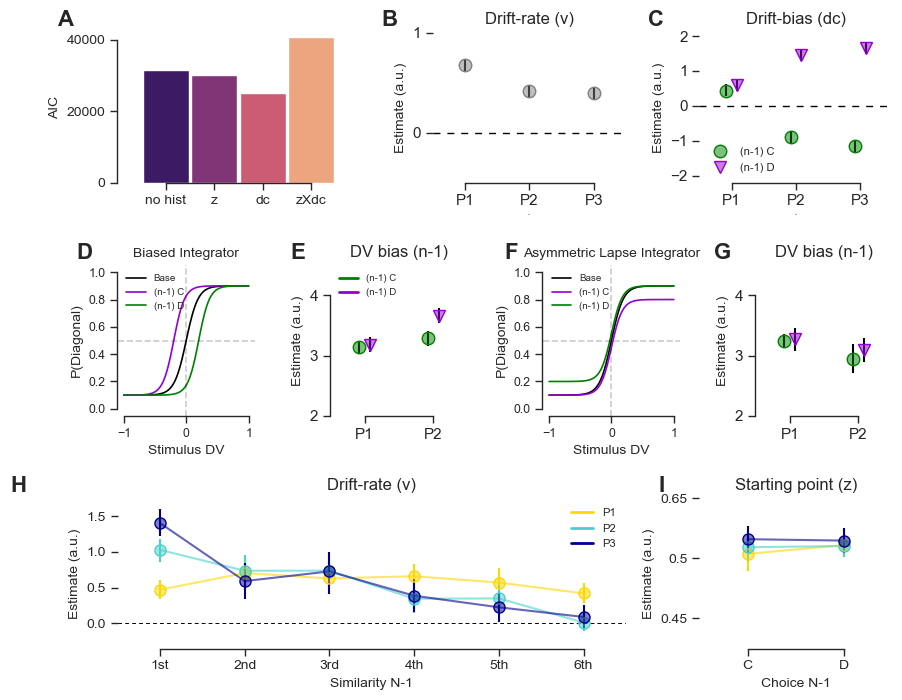

In [98]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import os
import string

EXP = '3reps'

# =================================================================
# FIGURE: 3 rows
#   Row 0: ax1 (wide), ax2, ax3          → A, B, C
#   Row 1: ax6, ax7, ax8, ax9            → D, E, F, G
#   Row 2: ax4 (spans 2 cols), ax5       → H, I
# =================================================================
fig = plt.figure(figsize=(10, 8))

outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

# --- Row 0: original top row (AIC + 2 DDM params) ---
inner_top = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer_gs[0], width_ratios=[1.25, 1, 1], wspace=0.35
)
ax1 = fig.add_subplot(inner_top[0, 0])
ax2 = fig.add_subplot(inner_top[0, 1])
ax3 = fig.add_subplot(inner_top[0, 2])

# --- Row 1: 4 new panels ---
inner_mid = gridspec.GridSpecFromSubplotSpec(
    1, 4, subplot_spec=outer_gs[1], wspace=0.55
)
ax6 = fig.add_subplot(inner_mid[0, 0])   # D: psychometric threshold shifts
ax7 = fig.add_subplot(inner_mid[0, 1])   # E: DV bias threshold_bias
ax8 = fig.add_subplot(inner_mid[0, 2])   # F: psychometric lapses
ax9 = fig.add_subplot(inner_mid[0, 3])   # G: DV bias lapse_bias

# --- Row 2: original bottom row (repetition similarity) ---
inner_bot = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer_gs[2], width_ratios=[1.25, 1, 1], wspace=0.35
)
ax4 = fig.add_subplot(inner_bot[0, 0:2])
ax5 = fig.add_subplot(inner_bot[0, 2])

axes_params = [ax2, ax3]

# =================================================================
# PANEL A: Model comparison (AIC)
# =================================================================
dat = modelfit[modelfit.exp_ID == EXP]
dat = dat[(dat.model != 'zXdcrepeat')]
dat['model'] = dat['model'].cat.remove_unused_categories()
g = sns.barplot(data=dat, x='model', y='aic', hue='model', dodge=False,
                linewidth=1, palette='magma', width=0.95, ax=ax1)
g.set_xlabel("Model", fontsize=10)
g.set_ylabel("AIC", fontsize=10)
g.legend(loc='best', fontsize=0, framealpha=0.0)
ax1.set_ylim(0., 42000)
ax1.set_yticks([0.0, 2e4, 4e4])
ax1.tick_params(axis='y', labelsize=10)
ax1.set_xticks([0, 1, 2, 3])
ax1.set_xticklabels(['no hist', 'z', 'dc', 'zXdc'])
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlabel(None)
ax1.set_xlim([-1, 4])
sns.despine(ax=ax1, offset=0.5, trim=True)
ax1.spines['bottom'].set_bounds(0, 3)

# =================================================================
# PANELS B & C: DDM params (v and dc)
# =================================================================
y_limits = np.array([[-0.5, 1], [-2.2, 2.1]])
estims = ddms_params[
    (ddms_params.exp_ID == EXP) & (ddms_params.model == 'stimcoding_dc_prevresp')
].copy()
estims['mean']  = estims['mean'].astype(float)
estims['2.5q']  = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)
sp_titles   = ['Drift-rate (v)', 'Drift-bias (dc)']
dodge_small = 0.08

for j, jparam in enumerate(['v', 'dc']):
    ax = axes_params[j]
    ax.set_title(sp_titles[j], fontsize=12)
    stim = estims[estims.param == jparam]
    ax.axhline(y=0, color='black', linewidth=1, linestyle='dashed', dashes=(5, 5))

    if jparam == 'dc':
        unique_prevr = np.unique(stim['prevr'])
        for h_idx, h_val in enumerate(unique_prevr):
            subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
            x_pos   = np.arange(len(subset['nrep'].unique())) + \
                      (dodge_small if h_idx == 1 else -dodge_small)
            y_vals  = subset['mean'].values
            yerr    = [np.abs(y_vals - subset['2.5q'].values),
                       np.abs(subset['97.5q'].values - y_vals)]
            base_col = colpal3[h_idx]
            face_col = mcolors.to_rgba(base_col, alpha=0.5)
            ax.errorbar(x_pos, y_vals, yerr=yerr,
                        fmt='o' if h_idx == 0 else 'v',
                        color=base_col, mfc=face_col, mec=base_col,
                        markersize=9, elinewidth=1.5, ecolor='black',
                        capsize=0, zorder=10)
        lines_leg = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=mcolors.to_rgba(colpal3[0], 0.5),
                   markeredgecolor=colpal3[0], markersize=9),
            Line2D([0], [0], marker='v', color='w',
                   markerfacecolor=mcolors.to_rgba(colpal3[1], 0.5),
                   markeredgecolor=colpal3[1], markersize=9)
        ]
        ax.legend(lines_leg, ['(n-1) C', '(n-1) D'],
                  loc='lower left', fontsize=8, framealpha=0.0)
    else:
        subset  = stim.sort_values('nrep')
        x_pos   = np.arange(len(subset['nrep'].unique()))
        y_vals  = subset['mean'].values
        yerr    = [np.abs(y_vals - subset['2.5q'].values),
                   np.abs(subset['97.5q'].values - y_vals)]
        base_col = 'gray'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt='o',
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.set_xlabel('nrep', fontsize=0)
    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['P1', 'P2', 'P3'])
    ax.set_yticks([-2, -1, 0, 1, 2]); ax.set_ylim(y_limits[j])
    ax.tick_params(axis='both', labelsize=11)
    ax.set_xlim([-0.5, 2.5])
    sns.despine(ax=ax, left=True, bottom=False, trim=True)
    ax.spines['bottom'].set_bounds(0, 2)

# =================================================================
# PANEL D [mid, col0]: Psychometric — threshold shifts
# =================================================================
stimulus_intensities = np.linspace(-1, 1, 100)

def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * \
           (1 / (1 + np.exp(-(slope + 10) * (x - threshold))))
    return prob

threshold = 0.0; slope = 0.5; lapse_low = 0.1; lapse_high = 0.1

pF_base = psychometric_function(stimulus_intensities, threshold,       slope,     lapse_low, lapse_high)
pF_C    = psychometric_function(stimulus_intensities, threshold - 0.2, slope + 1, lapse_low, lapse_high)
pF_D    = psychometric_function(stimulus_intensities, threshold + 0.2, slope + 1, lapse_low, lapse_high)

ax6.set_title('Biased Integrator', fontsize=10)
ax6.plot(stimulus_intensities, pF_base, color='black',      label='Base')
ax6.plot(stimulus_intensities, pF_C,    color='darkviolet', label='(n-1) C')
ax6.plot(stimulus_intensities, pF_D,    color='green',      label='(n-1) D')
ax6.axvline(0, ls='--', color='black', alpha=0.2)
ax6.axhline(0.5, ls='--', color='black', alpha=0.2)
ax6.set_xlabel('Stimulus DV', fontsize=10)
ax6.set_ylabel('P(Diagonal)', fontsize=10)
ax6.set_ylim(-0.05, 1.05)
ax6.legend(loc='upper left', fontsize=7, framealpha=0.0)
sns.despine(ax=ax6, trim=True, offset=0.5)

# =================================================================
# PANEL E [mid, col1]: DV bias — threshold_bias
# =================================================================
EXP_thresh  = 'threshold_bias'
est_thresh  = grouped_params[grouped_params.model == EXP_thresh].copy()
est_thresh["2.5_ci"]  = est_thresh["Estimate"] - est_thresh["sem"] * 1.96
est_thresh["97.5_ci"] = est_thresh["Estimate"] + est_thresh["sem"] * 1.96
stim_t      = est_thresh[est_thresh.parameter == 'DV']
prev_vals_t = np.unique(stim_t['pre_deci'])

ax7.set_title('DV bias (n-1)', fontsize=12)
ax7.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))
for h_idx, h_val in enumerate(prev_vals_t):
    subset  = stim_t[stim_t['pre_deci'] == h_val].sort_values('nrep')
    x_pos   = np.arange(len(np.unique(stim_t['nrep']))) + \
              (dodge_small if h_idx == 1 else -dodge_small)
    y_vals  = subset['Estimate'].values
    yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
               np.abs(subset['97.5_ci'].values - y_vals)]
    base_col = colpal3[h_idx]
    face_col = mcolors.to_rgba(base_col, alpha=0.5)
    marker   = 'o' if h_idx == 0 else 'v'
    ax7.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                 color=base_col, mfc=face_col, mec=base_col,
                 markersize=9, elinewidth=1.5, ecolor='black',
                 capsize=0, zorder=10)
ax7.legend(
    [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals_t))],
    ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=7, framealpha=0.0)
ax7.set_ylim([2, 4.5])
ax7.set_ylabel('Estimate (a.u.)', fontsize=10)
ax7.set_xticks([0, 1]); ax7.set_xticklabels(['P1', 'P2'])
ax7.set_xlim([-0.5, 1.5]); ax7.margins(x=0.2, y=0.2)
ax7.set_xlabel('', fontsize=0)
ax7.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax7, offset=0.5, trim=True)

# =================================================================
# PANEL F [mid, col2]: Psychometric — lapse shifts
# =================================================================
pH_base = psychometric_function(stimulus_intensities, threshold, slope,     lapse_low,        lapse_high)
pH_C    = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low,        lapse_high + 0.1)
pH_D    = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low + 0.1,  lapse_high)

ax8.set_title('Asymmetric Lapse Integrator', fontsize=10)
ax8.plot(stimulus_intensities, pH_base, color='black',      label='Base')
ax8.plot(stimulus_intensities, pH_C,    color='darkviolet', label='(n-1) C')
ax8.plot(stimulus_intensities, pH_D,    color='green',      label='(n-1) D')
ax8.axvline(0, ls='--', color='black', alpha=0.2)
ax8.axhline(0.5, ls='--', color='black', alpha=0.2)
ax8.set_xlabel('Stimulus DV', fontsize=10)
ax8.set_ylabel('P(Diagonal)', fontsize=10)
ax8.set_ylim(-0.05, 1.05)
ax8.legend(loc='upper left', fontsize=7, framealpha=0.0)
sns.despine(ax=ax8, trim=True, offset=0.5)

# =================================================================
# PANEL G [mid, col3]: DV bias — lapse_bias
# =================================================================
EXP_lapse  = 'lapse_bias'
est_lapse  = grouped_params[grouped_params.model == EXP_lapse].copy()
est_lapse["2.5_ci"]  = est_lapse["Estimate"] - est_lapse["sem"] * 1.96
est_lapse["97.5_ci"] = est_lapse["Estimate"] + est_lapse["sem"] * 1.96
stim_l      = est_lapse[est_lapse.parameter == 'DV']
prev_vals_l = np.unique(stim_l['pre_deci'])

ax9.set_title('DV bias (n-1)', fontsize=12)
ax9.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))
for h_idx, h_val in enumerate(prev_vals_l):
    subset  = stim_l[stim_l['pre_deci'] == h_val].sort_values('nrep')
    x_pos   = np.arange(len(np.unique(stim_l['nrep']))) + \
              (dodge_small if h_idx == 1 else -dodge_small)
    y_vals  = subset['Estimate'].values
    yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
               np.abs(subset['97.5_ci'].values - y_vals)]
    base_col = colpal3[h_idx]
    face_col = mcolors.to_rgba(base_col, alpha=0.5)
    marker   = 'o' if h_idx == 0 else 'v'
    ax9.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                 color=base_col, mfc=face_col, mec=base_col,
                 markersize=9, elinewidth=1.5, ecolor='black',
                 capsize=0, zorder=10)
ax9.set_ylim([2, 4.5])
ax9.set_ylabel('Estimate (a.u.)', fontsize=10)
ax9.set_xticks([0, 1]); ax9.set_xticklabels(['P1', 'P2'])
ax9.set_xlim([-0.5, 1.5]); ax9.margins(x=0.2, y=0.2)
ax9.set_xlabel('', fontsize=0)
ax9.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax9, offset=0.5, trim=True)

# =================================================================
# PANELS H & I: Repetition similarity params
# =================================================================
y_limits = np.array([[-0.35, 1.75], [0.425, 0.55]])
estims = params_reg[
    (params_reg.exp == EXP) & (params_reg.model == 'stimcoding_diffprev')
].copy()
estims['mean']  = estims['mean'].astype(float)
estims['2.5q']  = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)
parameters = ['v', 'z']
nreps      = [0, 1, 2]
lines_rep  = [Line2D([0], [0], color=c, linewidth=2) for c in colpal2]

for x, xparam in enumerate(parameters):
    for y, yrep in enumerate(nreps):
        stim     = estims[(estims.param == xparam) & (estims.nrep == yrep)]
        base_col = colpal2[y]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)

        if xparam == 'v':
            ax4.set_title('Drift-rate (v)', fontsize=12)
            x_coords = [stim['pos'].unique().tolist().index(cat) for cat in stim['pos']]
            y_coords = stim['mean'].values
            errs     = np.abs(np.array(stim[["2.5q", "97.5q"]]).T)
            ax4.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax4.errorbar(x_coords, y_coords, yerr=errs, fmt='o',
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col,
                         capsize=0, zorder=3)
            ax4.set_ylim(y_limits[0]); ax4.set_xlim([-0.5, 5.5])
            ax4.tick_params(axis='both', labelsize=10)
            ax4.legend(lines_rep, ['P1', 'P2', 'P3'],
                       loc='upper right', fontsize=8, framealpha=0.0)
            ax4.axhline(y=0, color='black', linewidth=0.5,
                        linestyle='dashed', dashes=(5, 5))
            for spine in ['top', 'right', 'left']:
                ax4.spines[spine].set_visible(False)
            ax4.set_xlabel('Similarity N-1', fontsize=10)
            ax4.set_ylabel('Estimate (a.u.)', fontsize=10)
            ax4.margins(x=0.2)
            ax4.set_xticks([0, 1, 2, 3, 4, 5])
            ax4.set_xticklabels(['1st', '2nd', '3rd', '4th', '5th', '6th'])
            ax4.spines['bottom'].set_bounds(0, 5)

        if xparam == 'z':
            ax5.set_title('Starting point (z)', fontsize=12)
            x_coords = [stim['prevr'].unique().tolist().index(cat) for cat in stim['prevr']]
            y_coords = stim['mean'].values
            errs     = np.abs(np.array(stim[["2.5q", "97.5q"]]).T)
            ax5.plot(x_coords, y_coords, color=base_col, linewidth=1.5, alpha=0.6, zorder=2)
            ax5.errorbar(x_coords, y_coords, yerr=errs, fmt='o',
                         color=base_col, mfc=face_col, mec=base_col,
                         markersize=8, elinewidth=1.5, ecolor=base_col,
                         capsize=0, zorder=3)
            ax5.set_ylim(y_limits[1]); ax5.set_xlim([-0.5, 1.5])
            ax5.tick_params(axis='both', labelsize=10)
            for spine in ['top', 'right', 'left']:
                ax5.spines[spine].set_visible(False)
            ax5.set_xlabel('Choice N-1', fontsize=10)
            ax5.set_ylabel('Estimate (a.u.)', fontsize=10)
            ax5.set_yticks([0.45, 0.5, 0.55])
            ax5.set_yticklabels([0.45, 0.5, 0.65])
            ax5.set_xticks([0, 1]); ax5.set_xticklabels(['C', 'D'])
            ax5.spines['bottom'].set_bounds(0, 1)

# =================================================================
# PANEL LABELS A–I
# =================================================================
axes_list    = [ax1, ax2, ax3, ax6, ax7, ax8, ax9, ax4, ax5]
panel_labels = list(string.ascii_uppercase)[:9]
for i, ax in enumerate(axes_list):
    ax.text(-0.18, 1.15, panel_labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

fig.tight_layout(pad=2)
# figpath = os.path.join(figures_path, '3reps_DDMreal_extended.pdf')
# plt.savefig(figpath, bbox_inches='tight', dpi=300)
plt.show()